# **NEW YORK JETS | NFL DRAFT 2025 PREDICTION MODEL**

**Team 1:**
* Angela Manrique
* Carlo Lauretano
* Harsh Avinash Prakash Kammath
* Iván de la Fuente
* Michelle Salas

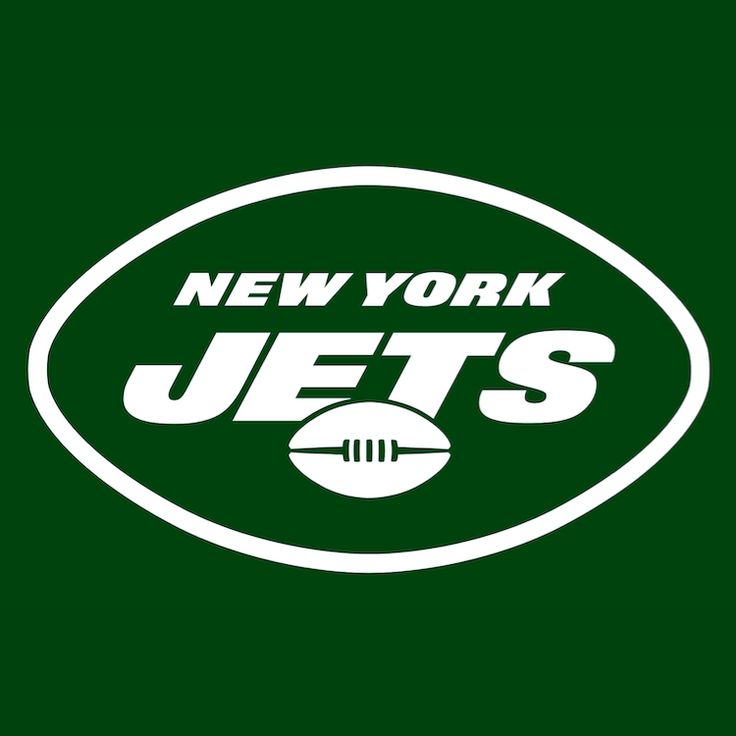

### **NOTEBOOK OBJECTIVE**

The goal of this project is to support the New York Jets' 2025 NFL Draft strategy through machine learning (ML). By analyzing historical draft data (2007–2023), the team aims to predict the probability of success for current draft prospects. This aligns with the Jets’ organizational objective of reaching the 2025–2026 playoffs, balancing analytics with franchise-specific business needs.

# MODEL TRAINING, VALIDATION AND TESTING

The dataset is split into positional groups: quarterbacks (QBs), running backs (RBs), wide receivers/tight ends (WRs/TEs), offensive linemen (OL), and defenders (DEF). These will be merged into a unified DataFrame with renamed and cleaned columns. After, the dataset unified will be used to train our models and validate the results. The best model will be used to forecast the future prospects for the franchise.

### IMPORT LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import ttest_ind

## DATA IMPORT

In [ ]:
# Load datasets
df_qb = pd.read_csv("QBs_def.csv")
df_rb = pd.read_csv("RBs_def.csv")
df_wrte = pd.read_csv("WRs_TEs_def.csv")
df_ol = pd.read_csv("OL_def.csv")
df_def = pd.read_csv("DEF_def.csv")

## DATA PREPARATION

Column Renaming

In [ ]:
df_def.rename(columns={'Pos_x': 'Pos'}, inplace=True)

In [ ]:
df_def.rename(columns={'COLLEGE': 'Team'}, inplace=True)

In [ ]:
df_rb.rename(columns={'Average_Grades_of_RBs_in_Year': 'Average_Grades_per_position_in_Year'}, inplace=True)

In [ ]:
df_qb.rename(columns={'Average_Grades_QBs_in_Year': 'Average_Grades_per_position_in_Year'}, inplace=True)

In the different csv files the naming of some columns is incosistent, so it has been applied the renaming of some of them to match the columns containing the same tyoe of data.

Column Dropping

In [ ]:
df_rb = df_rb.drop('wAV/G', axis=1)

In [ ]:
df_wrte = df_wrte.drop('wAV/G', axis=1)

In [ ]:
df_def = df_def.drop('wAV/G', axis=1)

In [ ]:
df_def = df_def.drop('position', axis=1)

In [ ]:
df_def = df_def.drop('grades_offense', axis=1)

Some columns are droped because:
* Calculated columns of already esisting paramters (redundant) --> e.g wAV/G
* Meaningless colums due to empty values or not utilized

Column Clustering

In [ ]:
# Create an array that contains the first 5 columns of the dataframes and call it '1.Pick Information'

pick_information = ["rnd", "pick", "tm", "player", "pos", "age"]
nfl_statistics = [
    "to", "ap1", "pb", "st", "wav", "drav", "g",
    "cmp_pass", "att_pass", "yds_pass", "td_pass", "int_pass",
    "att_rush", "yds_rush", "td_rush",
    "rec", "yds_rec", "td_rec",
    "tackles", "int_def", "sk"
]
pff_scores = ["grade_rookie_season", "career_avg_grade", "average_grades_qbs_in_year"]
ppf_scores_py = [
    "prev_year", "record", "pf", "pa", "over", "off", "pass", "pblk", "recv",
    "run", "rblk", "def", "rdef", "tack", "prsh", "cov", "spec", "year"
]
nfl_combine = ["ht_inches", "wt", "40yd", "vertical", "bench", "broad_jump", "3cone", "shuttle"]
college_statistics = [
    "college/univ", "year_drafted", "team", "total_games", "total_cmp", "total_att",
    "total_yds", "total_td", "total_int", "cmp_percentage", "td_percentage", "int_percentage",
    "y_a", "ay_a", "y_c", "y_g", "rate", "seasons_played",
    "total_rec", "total_rec_yds", "total_rec_td", "rec_y_r", "rec_y_g",
    "total_rush_att", "total_rush_yds", "total_rush_td", "rush_y_a", "rush_y_g",
    "total_plays", "blk", "rblk_x", "pblk_x", "off_x", "sk2", "hit", "hur", "pr",
    "eff", "pen", "lt", "lg", "c", "rg", "rt", "ite", "blk_p",
    "total_solo", "total_ast", "total_tackles", "total_sack", "total_sack_yds",
    "total_pd", "total_int_yds", "total_int_lng", "total_int_td", "total_ff"
]
tot_columns = pick_information + nfl_statistics + pff_scores + ppf_scores_py + nfl_combine + college_statistics

In [ ]:
college_statistics_qb =  [
    "College/Univ", "year_drafted", "Team", "Total_Games", "Total_Cmp", "Total_Att",
    "Total_Yds", "Total_TD", "Total_Int", "Cmp_Percentage", "TD_Percentage", "Int_Percentage",
    "Y_A", "AY_A", "Y_C", "Y_G", "Rate", "Seasons_Played"
]

college_statistics_rb = [
    "College/Univ", "year_drafted", "Team", "Total_Games",
    "Total_Rec", "Total_Rec_Yds", "Total_Rec_TD", "Rec_Y_R", "Rec_Y_G",
    "Total_Rush_Att", "Total_Rush_Yds", "Total_Rush_TD", "Rush_Y_A", "Rush_Y_G",
    "Total_Plays", "Total_Yds", "Total_TD", "Seasons_Played"
]

college_statistics_wrte = [
    "College/Univ", "year_drafted", "Team", "Total_Games",
    "Total_Rec", "Total_Rec_Yds", "Total_Rec_TD", "Rec_Y_R", "Rec_Y_G",
    "Total_Rush_Att", "Total_Rush_Yds", "Total_Rush_TD", "Rush_Y_A", "Rush_Y_G",
    "Total_Plays", "Total_Yds", "Total_TD", "Seasons_Played"
]

college_statistics_ol = [
    "College/Univ", "year_drafted", "Team", "Total_Games",
    "BLK", "RBLK_x", "PBLK_x", "OFF_x", "SK", "HIT", "HUR", "PR", "EFF", "PEN",
    "LT", "LG", "C", "RG", "RT", "ITE", "Seasons_Played", "BLK_P"
]

college_statistics_def = [
    "College/Univ", "year_drafted", "Team",
    "Total_Solo", "Total_Ast", "Total_Tackles",
    "Total_Sack", "Total_Sack_Yds", "Total_PD",
    "Total_Int", "Total_Int_Yds", "Total_Int_LNG",
    "Total_Int_TD", "Total_FF", "Seasons_Played"
]
tot_check = college_statistics_qb + college_statistics_rb + college_statistics_wrte + college_statistics_ol + college_statistics_def

In [ ]:
# Count elements in tot_columns

print(len(tot_columns))
print(len(tot_check))

112
91


The colums where clusterd in arrays to better manage them during the data cleaning and dataset preparation to facilitate the the machine learning models application

Data Merge

In [ ]:
# Merge all into one dataset
combined_df = pd.concat([df_qb, df_rb, df_wrte, df_ol, df_def], ignore_index=True)
combined_df.head()

,Rnd,Pick,Tm,Player,Pos,Age,To,AP1,PB,St,...,Total_Solo,Total_Ast,Total_Tackles,Total_Sack,Total_Sack_Yds,Total_PD,Total_Int_Yds,Total_Int_LNG,Total_Int_TD,Total_FF
0,1,1,CHI,Caleb Williams,QB,22.0,2024.0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,WAS,Jayden Daniels,QB,23.0,2024.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,NWE,Drake Maye,QB,22.0,2024.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,8,ATL,Michael Penix Jr.,QB,24.0,2024.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,10,MIN,J.J. McCarthy,QB,21.0,NaN,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop of a column that is useless for the analysis
combined_df = combined_df.drop('Sk', axis=1)

The column name 'Sk' has been dropped before the columns renaming to avoid the conflict with another column called 'sk' that is part of the palyer college statistics. In addiotn, the column 'Sk' is not useful for the analysis so can be deleted.

In [ ]:
combined_df.columns = combined_df.columns.str.strip()
combined_df.head()

,Rnd,Pick,Tm,Player,Pos,Age,To,AP1,PB,St,...,Total_Solo,Total_Ast,Total_Tackles,Total_Sack,Total_Sack_Yds,Total_PD,Total_Int_Yds,Total_Int_LNG,Total_Int_TD,Total_FF
0,1,1,CHI,Caleb Williams,QB,22.0,2024.0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,WAS,Jayden Daniels,QB,23.0,2024.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,NWE,Drake Maye,QB,22.0,2024.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,8,ATL,Michael Penix Jr.,QB,24.0,2024.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,10,MIN,J.J. McCarthy,QB,21.0,NaN,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Rename all the columns removing capital letters and substituting spaces with _

def clean_col_names(df):
  cols = df.columns
  new_cols = []
  for col in cols:
    new_col = col.lower().replace(' ', '_')
    new_cols.append(new_col)
  df.columns = new_cols
  return df

combined_df = clean_col_names(combined_df)

In [ ]:
# Count number of columns in the combined df

num_columns = len(combined_df.columns)
print(f"The number of columns in the DataFrame is: {num_columns}")

The number of columns in the DataFrame is: 112


In [ ]:
combined_df.describe()

,rnd,pick,age,to,ap1,pb,st,wav,drav,g,...,total_solo,total_ast,total_tackles,total_sack,total_sack_yds,total_pd,total_int_yds,total_int_lng,total_int_td,total_ff
count,4121.000000,4121.000000,4076.000000,3813.000000,4121.000000,4121.000000,4121.000000,3813.000000,3587.000000,3813.000000,...,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000
mean,4.141956,127.197768,22.439892,2019.816155,0.066246,0.264014,1.626304,14.621558,11.565375,54.272489,...,90.322228,60.955259,151.269396,6.979534,-10.947168,3.897668,40.740124,30.683484,0.371252,1.774869
std,1.987092,73.748849,0.939948,4.682415,0.416561,0.999606,2.497888,18.656593,15.694833,43.196372,...,45.954122,36.294141,75.746612,7.394339,65.475714,6.803255,62.124162,41.710011,0.735632,1.723854
min,1.000000,1.000000,20.000000,2007.000000,0.000000,0.000000,0.000000,-4.000000,-4.000000,0.000000,...,1.000000,0.000000,6.000000,0.000000,-252.000000,0.000000,-5.000000,-4.000000,0.000000,0.000000
25%,2.000000,63.000000,22.000000,2016.000000,0.000000,0.000000,0.000000,2.000000,2.000000,18.000000,...,56.000000,34.000000,97.000000,1.000000,-39.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,4.000000,126.000000,22.000000,2022.000000,0.000000,0.000000,0.000000,7.000000,6.000000,44.000000,...,82.000000,53.000000,137.000000,4.500000,0.000000,0.000000,12.000000,11.000000,0.000000,1.000000
75%,6.000000,191.000000,23.000000,2024.000000,0.000000,0.000000,2.000000,21.000000,15.000000,81.000000,...,117.000000,79.000000,191.000000,11.000000,13.000000,5.000000,61.000000,49.000000,1.000000,3.000000
max,7.000000,262.000000,28.000000,2024.000000,8.000000,10.000000,16.000000,146.000000,144.000000,261.000000,...,331.000000,244.000000,516.000000,45.000000,247.000000,45.000000,494.000000,248.000000,6.000000,12.000000


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4121 entries, 0 to 4120
Columns: 112 entries, rnd to total_ff
dtypes: float64(95), int64(7), object(10)
memory usage: 3.5+ MB


The position specific datasets have been merged in a unique dataframe to train the machine learning models. To stardardize the df, all the column were cleaned and renamed, removing spaces and capital letters to guarantee easy access and coding. After that the dataframe statistics and variables type has been studidied to proceed with the data preparation.

DATA TRASFORMATION TO BE INGESTED BY THE MODELS

In [ ]:
# Convert the column ht from feet-inches to inches only
def height_to_inches(height_str):
  if pd.isna(height_str):
    return np.nan
  parts = height_str.split('-')
  if len(parts) == 2:
    feet = int(parts[0])
    inches = int(parts[1])
    return feet * 12 + inches
  else:
    return np.nan

combined_df['ht_inches'] = combined_df['ht'].apply(height_to_inches)
combined_df = combined_df.drop('ht', axis=1)

Conversion of Height in feet_inches to inches only to remove the dash '-' and be used to train the models

In [ ]:
Median_fill_pos = ['wav', 'drav', 'ht_inches', 'wt']


In [ ]:
# Fill in with the median per postion the columns present in the array Median_fill_pos

for col in Median_fill_pos:
  combined_df[col] = combined_df.groupby('pos')[col].transform(lambda x: x.fillna(x.median()))

print(combined_df[Median_fill_pos].isnull().sum())


wav          0
drav         0
ht_inches    1
wt           1
dtype: int64


In [ ]:
# prompt: show the rows that are still null in the column ht and wt

print(combined_df[combined_df['ht_inches'].isnull() | combined_df['wt'].isnull()])

      rnd  pick   tm       player pos   age      to  ap1  pb  st  ...  \
3507    7   223  LVR  Trey Taylor  FS  23.0  2024.0    0   0   0  ...   

      total_ast  total_tackles  total_sack  total_sack_yds  total_pd  \
3507       85.0          205.0         2.5            29.0      13.0   

      total_int_yds  total_int_lng  total_int_td  total_ff  ht_inches  
3507          112.0           66.0           1.0       1.0        NaN  

[1 rows x 112 columns]


In [ ]:
# Drop that rows that still contains null values in Ht and Wt that is onòy one and it's one row for FS role (only one line for this postion)

combined_df.dropna(subset=['ht_inches', 'wt'], inplace=True)

print(combined_df[combined_df['ht_inches'].isnull() | combined_df['wt'].isnull()])

Empty DataFrame
Columns: [rnd, pick, tm, player, pos, age, to, ap1, pb, st, wav, drav, g, cmp_pass, att_pass, yds_pass, td_pass, int_pass, att_rush, yds_rush, td_rush, rec, yds_rec, td_rec, tackles, int_def, college/univ, year_drafted, team, total_games, total_cmp, total_att, total_yds, total_td, total_int, cmp_percentage, td_percentage, int_percentage, y_a, ay_a, y_c, y_g, rate, seasons_played, wt, 40yd, vertical, bench, broad_jump, 3cone, shuttle, teamdrafted, grade_rookie_season, career_avg_grade, average_grades_per_position_in_year, prev_year, record, pf, pa, over, off, pass, pblk, recv, run, rblk, def, rdef, tack, prsh, cov, spec, year, total_rec, total_rec_yds, total_rec_td, rec_y_r, rec_y_g, total_rush_att, total_rush_yds, total_rush_td, rush_y_a, rush_y_g, total_plays, blk, rblk_x, pblk_x, off_x, sk, hit, hur, pr, eff, pen, lt, lg, c, rg, rt, ite, ...]
Index: []

[0 rows x 112 columns]


In [ ]:
# Put a 0 in column SPEC that has a value equal to '-'

combined_df['spec'] = combined_df['spec'].replace('-', 0)
combined_df['spec'] = pd.to_numeric(combined_df['spec'], errors='coerce')

The columns wav, drav, ht_inches, wt were incomplete and containing multiple NaN that cannot be procces by the machine learing models. These NaN values have been filled in with the median per position to avoid changing the dataset distribution or impact on the postions clusters. This step is crucial to keep the datset consistent and obtain a robust model to predict the 2025 prospect without flooding the datset with 0 or removing rows. The option of removing the incomplete rows has been evalueted but adbandoned becuase it would have lead to more than thousands of rows, corrupting the model robustness.

In [ ]:
# Identify the index of the rows that contains a null in the column 'college/univ'

print(combined_df[combined_df['college/univ'].isnull()].index)


Index([873, 1656, 1660, 3500], dtype='int64')


In [ ]:
# Fill the row empty in college/univ with the Unknown

# Replace NaN in 'college/univ'
combined_df['college/univ'].fillna('Unknown', inplace=True)

print(combined_df[combined_df['college/univ'].isnull()].index)

Index([], dtype='int64')


<ipython-input-88-8d09bd0976c1>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['college/univ'].fillna('Unknown', inplace=True)


Fill in the empty values in the column 'college/univ' with the label "Unknown" to secure the avoidance on NaN for the ML models.

In [ ]:
# Identify the index of the rows that contains a null in the column 'college/univ'

print(combined_df[combined_df['grade_rookie_season'].isnull()].index)
print(combined_df[combined_df['career_avg_grade'].isnull()].index)

Index([373, 812, 904, 1438, 2283, 2442, 2567, 2657, 2694, 3078, 3178, 3488], dtype='int64')
Index([373, 812, 904, 1438, 2283, 2442, 2567, 2657, 2694, 3078, 3178, 3488], dtype='int64')


In [ ]:
# Fill in this values with the median per position since the single player stats are not available

# Convert 'grade_rookie_season' and 'career_avg_grade' to numeric, coercing errors to NaN
combined_df['grade_rookie_season'] = pd.to_numeric(combined_df['grade_rookie_season'], errors='coerce')
combined_df['career_avg_grade'] = pd.to_numeric(combined_df['career_avg_grade'], errors='coerce')

# Fill in the null values with the median per position
combined_df['grade_rookie_season'] = combined_df.groupby('pos')['grade_rookie_season'].transform(lambda x: x.fillna(x.median()))
combined_df['career_avg_grade'] = combined_df.groupby('pos')['career_avg_grade'].transform(lambda x: x.fillna(x.median()))

print(combined_df[['grade_rookie_season', 'career_avg_grade']].isnull().sum())

grade_rookie_season    0
career_avg_grade       0
dtype: int64


As already done for some previous paraemters, also the columns 'grade_rookie_season' and 'career_avg_grade' with the median per postion to avoid dat distortion, while granting consistency for the model.

In [ ]:
columns_drop = [
    'rnd', 'pick', 'tm'#, 'player'
    , 'age', 'to', 'ap1', 'pb', 'st', 'g',
    'cmp_pass', 'att_pass', 'yds_pass', 'td_pass', 'int_pass',
    'att_rush', 'yds_rush', 'td_rush',
    'rec', 'yds_rec', 'td_rec',
    'tackles', 'int_def',
    'team', 'teamdrafted'
]

In [ ]:
# drop columns_drop becuase are NFL related columns not useful for the predictions (keeping only the y target variables)

combined_df = combined_df.drop(columns=columns_drop)

Dropping columns that are not useful for the analysis and are related to the NFL statistics. For this reason thess columns cannot be use for the prediction in the model because they will not be available in the prospect dataset in which the predictions are required.

In [ ]:
# Convert all the columns in nfl_combine array in numeric format

for col in nfl_combine:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Check the data types to confirm the conversion
print(combined_df[nfl_combine].describe())

         ht_inches           wt         40yd     vertical        bench  \
count  4120.000000  4120.000000  3105.000000  2817.000000  2278.000000   
mean     73.743204   238.164442     4.683810    33.704579    20.596137   
std       2.506816    42.503290     0.264542     3.973795     6.267021   
min      65.000000   155.000000     4.210000    19.500000     2.000000   
25%      72.000000   202.000000     4.490000    31.000000    16.000000   
50%      74.000000   229.000000     4.610000    34.000000    20.000000   
75%      76.000000   265.000000     4.840000    36.500000    25.000000   
max      81.000000   384.000000     5.850000    45.000000    49.000000   

        broad_jump        3cone      shuttle  
count  2765.000000  2030.000000  2108.000000  
mean    117.698011     7.170044     4.365816  
std       8.475402     0.360917     0.233773  
min      82.000000     6.440000     3.810000  
25%     112.000000     6.910000     4.200000  
50%     118.000000     7.090000     4.330000  
75% 

In [ ]:
# Label Encoding for 40 yrads to mange NaN

def bin_40yd(row):
    pos = row['pos']
    val = row['40yd']

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'WR':
            return 'Outstanding' if val <= 4.22 else 'Red Flag' if val >= 4.85 else 'Average'
        elif pos == 'CB':
            return 'Outstanding' if val <= 4.28 else 'Red Flag' if val >= 4.75 else 'Average'
        elif pos == 'S':
            return 'Outstanding' if val <= 4.29 else 'Red Flag' if val >= 4.83 else 'Average'
        elif pos == 'RB':
            return 'Outstanding' if val <= 4.31 else 'Red Flag' if val >= 4.78 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 4.38 else 'Red Flag' if val >= 4.98 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 4.42 else 'Red Flag' if val >= 5.05 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 4.41 else 'Red Flag' if val >= 5.27 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['forty_yd_grade'] = combined_df.apply(bin_40yd, axis=1)
combined_df = combined_df.drop('40yd', axis=1)

In [ ]:
def bin_bench_press(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('bench', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'DT':
            return 'Outstanding' if val >= 42 else 'Red Flag' if val <= 17 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val >= 39 else 'Red Flag' if val <= 12 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val >= 31 else 'Red Flag' if val <= 11 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 35 else 'Red Flag' if val <= 14 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val >= 31 else 'Red Flag' if val <= 14 else 'Average'
        elif pos == 'CB':
            return 'Outstanding' if val >= 22 else 'Red Flag' if val <= 4 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['bench_grade'] = combined_df.apply(bin_bench_press, axis=1)
combined_df = combined_df.drop('bench', axis=1)

In [ ]:
def bin_vertical_jump(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('vertical', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'CB':
            return 'Outstanding' if val >= 43 else 'Red Flag' if val <= 29.5 else 'Average'
        elif pos == 'WR':
            return 'Outstanding' if val >= 43.5 else 'Red Flag' if val <= 26.5 else 'Average'
        elif pos == 'RB':
            return 'Outstanding' if val >= 41.5 else 'Red Flag' if val <= 28.0 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 41 else 'Red Flag' if val <= 24.5 else 'Average'
        elif pos == 'TE':
            return 'Outstanding' if val >= 41.5 else 'Red Flag' if val <= 27.0 else 'Average'
        elif pos == 'DT':
            return 'Outstanding' if val >= 36 else 'Red Flag' if val <= 20.5 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['vertical_grade'] = combined_df.apply(bin_vertical_jump, axis=1)
combined_df = combined_df.drop('vertical', axis=1)

In [ ]:
def bin_broad_jump(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('broad_jump', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'RB':
            return 'Outstanding' if val >= 135 else 'Red Flag' if val <= 108 else 'Average'
        elif pos == 'WR':
            return 'Outstanding' if val >= 141 else 'Red Flag' if val <= 110 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 134 else 'Red Flag' if val <= 96 else 'Average'
        elif pos == 'TE':
            return 'Outstanding' if val >= 134 else 'Red Flag' if val <= 106 else 'Average'
        elif pos == 'OT':
            return 'Outstanding' if val >= 121 else 'Red Flag' if val <= 82 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val >= 117 else 'Red Flag' if val <= 88 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['broad_jump_grade'] = combined_df.apply(bin_broad_jump, axis=1)
combined_df = combined_df.drop('broad_jump', axis=1)

In [ ]:
def bin_3cone(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('3cone', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'S':
            return 'Outstanding' if val <= 6.85 else 'Red Flag' if val >= 7.29 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 6.92 else 'Red Flag' if val >= 7.35 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 6.92 else 'Red Flag' if val >= 7.40 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 7.09 else 'Red Flag' if val >= 7.48 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['3_cone_grade'] = combined_df.apply(bin_3cone, axis=1)
combined_df = combined_df.drop('3cone', axis=1)

In [ ]:
def bin_shuttle(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('shuttle', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'CB':
            return 'Outstanding' if val <= 3.89 else 'Red Flag' if val >= 4.56 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 4.00 else 'Red Flag' if val >= 4.57 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 4.03 else 'Red Flag' if val >= 4.51 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 4.00 else 'Red Flag' if val >= 4.96 else 'Average'
        elif pos == 'DT':
            return 'Outstanding' if val <= 4.27 else 'Red Flag' if val >= 5.07 else 'Average'
        elif pos == 'OT':
            return 'Outstanding' if val <= 4.40 else 'Red Flag' if val >= 5.38 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val <= 4.27 else 'Red Flag' if val >= 5.38 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

combined_df['shuttle_grade'] = combined_df.apply(bin_shuttle, axis=1)
combined_df = combined_df.drop('shuttle', axis=1)

In [ ]:
# Define the mapping dictionary
grade_mapping = {
    'Unknown': 0,
    'Red Flag': 1,
    'Average': 2,
    'Outstanding': 3
}

# List of columns to encode
grade_columns = [
    'forty_yd_grade', 'bench_grade', 'vertical_grade',
    'broad_jump_grade', '3_cone_grade', 'shuttle_grade'
]

# Apply the mapping
combined_df[grade_columns] = combined_df[grade_columns].map(lambda x: grade_mapping.get(x, 0))


In this section all the parameters related to the NFL combine has been clustered in bins based on the NFL evaluation metrics:
* Outstanding
* Average
* Red Flag

For each postion, the players has been clustered in this three bins based on the average performances the same player positions. In addtion, if the player didn't participate in the NFL combine or he didn't do a specific drill, that data has been included in the cluster 'Unknown'.

After the binning, the 3 clusters plus the 'Unknown' class has been encodedn with numbers from 0 to 3 ('Unknown' - 'Outstanding').

In [ ]:
# Remove whitespace and split the 'record' column by "-"
split_record = combined_df['record'].str.replace(" ", "").str.split("-", expand=True)

# Convert parts to numeric, safely
split_record = split_record.apply(pd.to_numeric, errors='coerce')

# Assign W–T–L based on number of parts
combined_df['win'] = split_record[0]
combined_df['tie'] = split_record[2] if split_record.shape[1] == 3 else 0
combined_df['loss'] = split_record[1]

# Fill tie with 0 if it's NaN (i.e., only W-L provided)
combined_df['tie'] = combined_df['tie'].fillna(0).astype(int)

The column record has been trasformedbecuase it was a format object64 containg a dash as character. 3 new columns have been created to manage the possible results of a NFL team:
* win
+ tie
* loss
In case the team doesn't have a tie the column has been filled with zero.

ONE-HOT ENCODING

In [ ]:
# One-Hot Encode the 'pos' column
df_encoded = pd.get_dummies(combined_df, columns=['pos'], prefix='pos',dtype=int)

# Display the first few rows of the new DataFrame with encoded columns
print(df_encoded.head())

# Display the column names to see the new one-hot encoded columns
df_encoded.columns

              player   wav  drav    college/univ  year_drafted  total_games  \
0     Caleb Williams  12.0  12.0             USC          2024         37.0   
1     Jayden Daniels  20.0  20.0             LSU          2024         55.0   
2         Drake Maye   8.0   8.0  North Carolina          2024         30.0   
3  Michael Penix Jr.   2.0   2.0      Washington          2024         48.0   
4      J.J. McCarthy   6.0   5.0        Michigan          2024         40.0   

   total_cmp  total_att  total_yds  total_td  ...  pos_OL  pos_OLB  pos_OT  \
0      735.0     1099.0    10082.0      93.0  ...       0        0       0   
1      953.0     1438.0    12749.0      89.0  ...       0        0       0   
2      618.0      952.0     8018.0      63.0  ...       0        0       0   
3     1067.0     1685.0    13741.0      96.0  ...       0        0       0   
4      482.0      713.0     6226.0      49.0  ...       0        0       0   

   pos_QB  pos_RB  pos_S  pos_SAF  pos_T  pos_TE  pos_WR

Index(['player', 'wav', 'drav', 'college/univ', 'year_drafted', 'total_games',
       'total_cmp', 'total_att', 'total_yds', 'total_td',
       ...
       'pos_OL', 'pos_OLB', 'pos_OT', 'pos_QB', 'pos_RB', 'pos_S', 'pos_SAF',
       'pos_T', 'pos_TE', 'pos_WR'],
      dtype='object', length=111)

In [ ]:
# One-Hot Encode the 'college/univ' column
df_encoded = pd.get_dummies(df_encoded, columns=['college/univ'], prefix='college_univ',dtype=int)

# Display the first few rows of the new DataFrame with encoded columns
print(df_encoded.head())

# Display the column names to see the new one-hot encoded columns
df_encoded.columns


              player   wav  drav  year_drafted  total_games  total_cmp  \
0     Caleb Williams  12.0  12.0          2024         37.0      735.0   
1     Jayden Daniels  20.0  20.0          2024         55.0      953.0   
2         Drake Maye   8.0   8.0          2024         30.0      618.0   
3  Michael Penix Jr.   2.0   2.0          2024         48.0     1067.0   
4      J.J. McCarthy   6.0   5.0          2024         40.0      482.0   

   total_att  total_yds  total_td  total_int  ...  college_univ_Wheaton  \
0     1099.0    10082.0      93.0       14.0  ...                     0   
1     1438.0    12749.0      89.0       20.0  ...                     0   
2      952.0     8018.0      63.0       16.0  ...                     0   
3     1685.0    13741.0      96.0       34.0  ...                     0   
4      713.0     6226.0      49.0       11.0  ...                     0   

   college_univ_Whitworth  college_univ_William & Mary  college_univ_Wingate  \
0                       

Index(['player', 'wav', 'drav', 'year_drafted', 'total_games', 'total_cmp',
       'total_att', 'total_yds', 'total_td', 'total_int',
       ...
       'college_univ_Wheaton', 'college_univ_Whitworth',
       'college_univ_William & Mary', 'college_univ_Wingate',
       'college_univ_Winston-Salem St.', 'college_univ_Wisconsin',
       'college_univ_WisconsinâWhitewater', 'college_univ_Wyoming',
       'college_univ_Yale', 'college_univ_Youngstown St.'],
      dtype='object', length=384)

In [ ]:
df_encoded.describe()

,wav,drav,year_drafted,total_games,total_cmp,total_att,total_yds,total_td,total_int,cmp_percentage,...,college_univ_Wheaton,college_univ_Whitworth,college_univ_William & Mary,college_univ_Wingate,college_univ_Winston-Salem St.,college_univ_Wisconsin,college_univ_WisconsinâWhitewater,college_univ_Wyoming,college_univ_Yale,college_univ_Youngstown St.
count,4120.000000,4120.000000,4120.000000,1720.000000,200.000000,200.000000,1342.000000,1342.000000,2300.00000,200.000000,...,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000,4120.000000
mean,14.082524,10.836165,2015.935922,38.849419,666.365000,1062.730000,3200.330849,26.697466,4.86913,62.237000,...,0.000243,0.000243,0.001699,0.000243,0.000243,0.012136,0.000485,0.002913,0.000971,0.000728
std,18.068773,14.780308,5.185959,10.191648,246.388001,383.988454,2703.262148,22.008526,7.80620,5.137157,...,0.015579,0.015579,0.041189,0.015579,0.015579,0.109506,0.022030,0.053897,0.031147,0.026978
min,-4.000000,-4.000000,2007.000000,1.000000,1.000000,4.000000,11.000000,0.000000,0.00000,25.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2011.000000,33.000000,516.750000,831.500000,1538.250000,12.000000,0.00000,59.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,6.000000,2016.000000,39.000000,669.500000,1092.500000,2416.500000,20.000000,2.00000,62.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,19.000000,13.000000,2020.000000,47.000000,812.500000,1315.500000,3728.000000,33.750000,6.00000,65.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,146.000000,144.000000,2024.000000,70.000000,1404.000000,2183.000000,16646.000000,131.000000,64.00000,74.300000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The two parameters 'pos' and 'college/univ' have been encoded with a get.dummies fuction becuase they are string and cannot be categorized in bins.

In this way the model will be ablet to use these columns as x-variables to define the predictions.

COLLEGE STATISTICS | LABEL ENCODING BASED ON NaN AND PERCENTILES

In [ ]:
# Step 1 – Define function to bin into 4 quantiles + 0 for NaNs
def bin_into_five_categories(series, suffix='_bin5'):
    """
    Bins a numeric column into 5 categories:
    - 0: NaN
    - 1–4: Quantile bins
    """
    binned_col = pd.Series(index=series.index, dtype="float")

    try:
        non_null_series = series.dropna()
        if not non_null_series.empty:
            with np.errstate(invalid='ignore'):
                q_bins = pd.qcut(non_null_series, q=4, labels=[1, 2, 3, 4], duplicates='drop')
            binned_col[series.notna()] = q_bins.astype(float)
    except ValueError:
        binned_col[series.notna()] = np.nan

    binned_col = binned_col.fillna(0)
    return binned_col.rename(series.name + suffix).astype(int)

# Step 2 – Define target columns
le_quantile_columns = [
    'total_games', 'total_cmp', 'total_att', 'total_yds', 'total_td', 'total_int',
    'cmp_percentage', 'td_percentage', 'int_percentage', 'y_a', 'ay_a', 'y_c', 'y_g',
    'rate', 'seasons_played', 'ht_inches', 'wt',
    'total_rec', 'total_rec_yds', 'total_rec_td', 'rec_y_r', 'rec_y_g',
    'total_rush_att', 'total_rush_yds', 'total_rush_td', 'rush_y_a', 'rush_y_g',
    'total_plays', 'blk', 'rblk_x', 'pblk_x', 'off_x', 'sk', 'hit', 'hur', 'pr',
    'eff', 'pen', 'lt', 'lg', 'c', 'rg', 'rt', 'ite', 'blk_p',
    'total_solo', 'total_ast', 'total_tackles', 'total_sack', 'total_sack_yds',
    'total_pd', 'total_int_yds', 'total_int_lng', 'total_int_td', 'total_ff'
]

# Step 3 – Clean and prepare for binning
bin5_encoded = {}

for col in le_quantile_columns:
    if col in df_encoded.columns:
        numeric_series = pd.to_numeric(df_encoded[col], errors='coerce')
        encoded_series = bin_into_five_categories(numeric_series)
        # Align to df_encoded index to avoid concat issues
        bin5_encoded[col + '_bin5'] = encoded_series.reindex(df_encoded.index)
    else:
        print(f"Column '{col}' not found in df_encoded — skipped.")

# Step 4 – Remove existing _bin5 columns (if any) to avoid duplication
df_encoded = df_encoded.drop(columns=[col for col in df_encoded.columns if col.endswith('_bin5')], errors='ignore')

# Step 5 – Safely add new binned columns
df_encoded = pd.concat([df_encoded, pd.DataFrame(bin5_encoded)], axis=1)


In [ ]:
# Drop the columns in the df_encoded that are contained in the array le_quantile_columns

df_encoded = df_encoded.drop(columns=le_quantile_columns, errors='ignore')
df_encoded = df_encoded.drop('record', axis=1)

All the columns related to the collge statistics have been clutered in 4 bins:
* Unknown
* First Percentile (x <= 25%)
* Second Percentile (25% < x <= 50%)
* Third Percentile (50% < x <= 75%)
* Fourth Percentile (x > 75%)

The percentiles were calculated for each parameter in the college statistics and after the values where placed in the corrispondent bin based on their values.

SUCCESS METRIC DEFINITION

In [ ]:
# New column called rookies success that is the difference between average_grades_per_position_in_year and grade_rookie_season

df_encoded['rookies_success'] = df_encoded['grade_rookie_season']- df_encoded['average_grades_per_position_in_year']

Definition of rookie_success as the difference between grade_rookie_season and average_grades_per_position_in_year. In case the difference is postitive it means that the player has overperformed in relation to his peers in the first year in NFL based on his postions.

In [ ]:
# Add to the data frame the column player name and pos retriving them form the combined_df based on the index

df_encoded[['player', 'career_avg_grade','drav','wav','rookies_success' ]].sort_values(by='career_avg_grade',ascending=False)


,player,career_avg_grade,drav,wav,rookies_success
8,Joe Milton,95.80,1.0,1.0,22.978261
2554,Aaron Donald,92.75,123.0,123.0,29.463158
2165,Jonas Mouton,92.50,0.0,0.0,-58.016667
2452,Jordan Brailford,92.10,6.0,1.0,-62.137500
1728,Christian Mahogany,91.50,1.0,1.0,36.070000
...,...,...,...,...,...
2351,Derek Parish,0.00,4.5,4.0,-55.880952
3533,Daniel Scott,0.00,9.0,12.0,-61.365217
89,Brad Kaaya,0.00,5.0,6.0,-71.835897
90,Chad Kelly,0.00,0.0,0.0,-71.835897


In [ ]:
# Drop the player column

df_encoded = df_encoded.drop('player', axis=1)

In [ ]:
# Use min/max method to normalize the columns drav, wav, career_avg_score, rookie_season_grade

from sklearn.preprocessing import MinMaxScaler

# List of columns to normalize
columns_to_normalize = ['drav', 'wav', 'career_avg_grade', 'rookies_success']

# Apply Min-Max normalization
scaler = MinMaxScaler()
df_encoded[columns_to_normalize] = scaler.fit_transform(df_encoded[columns_to_normalize])

# Print the first few rows to verify
print(df_encoded[columns_to_normalize].head())


       drav       wav  career_avg_grade  rookies_success
0  0.108108  0.106667          0.700418         0.622603
1  0.162162  0.160000          0.945720         0.834818
2  0.081081  0.080000          0.731733         0.649694
3  0.040541  0.040000          0.917537         0.810436
4  0.060811  0.066667          0.000000         0.016660


The variables 'drav', 'wav', career_avg_grade', 'rookies_success' has been normalize to using the min/max method to be used as success metrics in the models.

In [ ]:
# Create a new column called success_metric that is the weighted avg of parameter normalized above

# Weights for the metrics (these can be adjusted based on domain knowledge or feature importance analysis)
weights = {
    'drav': 0.15,
    'wav': 0.10,
    'career_avg_grade': 0.7,
    'rookies_success': 0.05
}

# Create the 'success_metric' column using the weighted average of the normalized metrics
df_encoded['success_metric_num'] = (
    df_encoded['drav'] * weights['drav'] +
    df_encoded['wav'] * weights['wav'] +
    df_encoded['career_avg_grade'] * weights['career_avg_grade'] +
    df_encoded['rookies_success'] * weights['rookies_success']
)

# prompt: create a column that is 1 if the value in that row for the column success_metric_num is aobe the 75 percentile

df_encoded['success_metric'] = (df_encoded['success_metric_num'] > df_encoded['success_metric_num'].quantile(0.75)).astype(int)

# Print the first few rows including the new column
print(df_encoded[['drav', 'wav', 'career_avg_grade', 'rookies_success', 'success_metric']].head())

       drav       wav  career_avg_grade  rookies_success  success_metric
0  0.108108  0.106667          0.700418         0.622603               1
1  0.162162  0.160000          0.945720         0.834818               1
2  0.081081  0.080000          0.731733         0.649694               1
3  0.040541  0.040000          0.917537         0.810436               1
4  0.060811  0.066667          0.000000         0.016660               0


Motivation for the Success Metric Definition and Weights:

Defining a composite success metric for NFL draft picks requires aligning both on-field performance and long-term value creation with franchise goals. The selected variables—Draft Value Added (DRAV), Wins Above Value (WAV), Career Average Grade, and Rookie Success—capture complementary dimensions of a player's impact. The applied weights reflect the New York Jets’ strategic emphasis on sustained, high-level performance while considering draft capital efficiency and early return on investment.

1. Career Average Grade (Weight = 0.70)

 This variable receives the highest weight (70%) because it encapsulates consistent, long-term player performance, as graded by analytics platforms such as PFF. For a franchise like the New York Jets seeking playoff relevance and roster stability, long-term productivity outweighs short-term flashes. Players with higher average grades across seasons signal durability, scheme adaptability, and high football IQ—traits critical for franchise building (Pro Football Focus, 2023; Schatz et al., 2023).

 Strategic logic: Starters who consistently perform above league average are more valuable than rookies who peak early and regress.

2. Draft Value Added (DRAV) (Weight = 0.15)

 DRAV quantifies the surplus value a player provides relative to their draft position. Weighting this at 15% reflects an acknowledgment of smart drafting strategy—finding value beyond expected pick performance. For cap-conscious franchises, maximizing value-per-pick supports deeper rosters and more flexibility under the salary cap (Brandt, 2022).

 Strategic logic: A 4th-round starter is more valuable financially and strategically than a 1st-round bust.

3. Wins Above Value (WAV) (Weight = 0.10)

 WAV estimates a player's contribution to team wins, providing a tangible link between individual output and franchise success. A moderate weight of 10% reflects its outcome-oriented nature while accounting for the fact that wins are influenced by many variables beyond a single player (Burke, 2021).

 Strategic logic: While wins are key, isolating a player's direct impact can be noisy—hence a moderate weight.

4. Rookie Success (Weight = 0.05)

 Rookie-year performance is a useful early signal, particularly for positions with steep learning curves. However, its weight is kept low (5%) to avoid overemphasizing early success at the expense of long-term consistency. Many elite players blossom after their rookie seasons due to scheme fit, coaching, or development time (Sando, 2022).

 Strategic logic: The Jets want sustainable starters, not just early risers.

In [ ]:
# Important: check the class imbalance to pick the right metric

df_encoded['success_metric'].value_counts()

,count
success_metric,
0,3090
1,1030


In [ ]:
# prompt: drop this columns 'drav', 'wav', 'career_avg_grade', 'rookies_success' and success_metric_num

columns_to_drop_final = ['drav', 'wav', 'career_avg_grade', 'rookies_success', 'success_metric_num','grade_rookie_season','average_grades_per_position_in_year']
df_encoded = df_encoded.drop(columns=columns_to_drop_final, errors='ignore')

Verification of the success class imbalance to verify if the success metric is meaningful and it's classifing players properly. Once the metric of success has been created as numeric values (0-100), it has been also binarized as:
* 1 = Successful player
* 0 = Unsuccesful player

After that all the columns used to syntetize the success metric have been dropped becuase redundant with the final success metric.

TRAINING, VALIDATION AND TESTING DEFINITON BASED ON TIME SERIES (year_drafted)

In [ ]:
# Converting the dates to date format (as it was in object format)

df_encoded['year_drafted'] = pd.to_datetime(df_encoded['year_drafted'], format='%Y')

In [ ]:
# Ensure the data is sorted by search date
df_encoded = df_encoded.sort_values(by="year_drafted")
# Extract features from srch_ci (Check-in Date)
df_encoded["year_drafted"] = df_encoded["year_drafted"].dt.year
df_encoded["year_drafted"].head()

,year_drafted
4120,2007
3174,2007
3175,2007
3176,2007
3177,2007


In [ ]:
# Define the split index (70% training, 15% validation, 15% testing)
n_total = len(df_encoded)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

# Split the data
X_train = df_encoded.iloc[:train_end].drop("success_metric", axis=1)
y_train = df_encoded.iloc[:train_end]["success_metric"]

X_val = df_encoded.iloc[train_end:val_end].drop("success_metric", axis=1)
y_val = df_encoded.iloc[train_end:val_end]["success_metric"]

X_test = df_encoded.iloc[val_end:].drop("success_metric", axis=1)
y_test = df_encoded.iloc[val_end:]["success_metric"]

The training, validation and testing dataset have been defined with temporality. The dataset has been orderded by draft year and after has been splitted in:
* 70% training
* 15% validation
* 15% testing

In this way, the data in the past have been used to predict the future.
For this type of dataset with a datetime reference, it is mandatory to avoid cross-validation and stratification because this approaches, for sure guarantee an higher model reliability and preserve the class distribution, but they don't care about data timestamp and in case of time series, they mix the data randomly causing inconsistencies, like predicting the past with future data.

The independent variables Xi are all the one contained on the dataframe df_ecnoded excepet for 'success_metric' that is the Y dependent variable for the models.

In [ ]:
X_train.describe()

,year_drafted,prev_year,pf,pa,over,off,pass,pblk,recv,run,...,total_solo_bin5,total_ast_bin5,total_tackles_bin5,total_sack_bin5,total_sack_yds_bin5,total_pd_bin5,total_int_yds_bin5,total_int_lng_bin5,total_int_td_bin5,total_ff_bin5
count,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,...,2884.000000,2884.000000,2884.000000,2884.000000,2884.000000,2884.0,2884.000000,2884.000000,2884.0,2884.0
mean,2013.315187,2012.315187,368.863731,372.985784,80.295874,75.691019,69.234570,75.957074,73.526526,64.248960,...,1.330444,1.327323,1.333911,1.265603,0.972607,0.0,1.246879,1.247573,0.0,0.0
std,3.833080,3.833080,89.161316,50.303796,8.602934,7.547979,12.027598,7.851793,7.792977,11.356183,...,1.517625,1.507871,1.516866,1.472437,1.128085,0.0,1.499708,1.499362,0.0,0.0
min,2007.000000,2006.000000,168.000000,216.000000,52.000000,57.300000,36.100000,51.200000,47.900000,33.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
25%,2010.000000,2009.000000,301.000000,335.000000,74.200000,70.300000,60.100000,70.700000,68.500000,56.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
50%,2013.000000,2012.000000,360.500000,373.000000,80.600000,76.000000,69.000000,76.500000,73.600000,64.500000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,0.0
75%,2017.000000,2016.000000,428.000000,406.000000,86.525000,81.225000,77.900000,81.600000,79.100000,72.000000,...,3.000000,3.000000,3.000000,3.000000,2.000000,0.0,3.000000,3.000000,0.0,0.0
max,2020.000000,2019.000000,664.000000,517.000000,95.800000,94.100000,93.600000,95.300000,92.700000,90.800000,...,4.000000,4.000000,4.000000,4.000000,4.000000,0.0,4.000000,4.000000,0.0,0.0


In [ ]:
# Remember that we need to scale the data

from sklearn.preprocessing import MinMaxScaler # You can also use standard scaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

The X variables have been scaled because some models need normilized data, like kNN and NN, sicne they woek on distancies to determine the class of the data points.

##### MODEL PERFORMANCE EVALUATION BASED ON PRECISION

Precsion:

Given the New York Jets’ 14-season playoff drought and current roster rebuild, precision was prioritized to minimize the risk of selecting busts in the 2025 draft. Especially in the first 4 rounds, every selection must deliver high impact. Precision measures the proportion of predicted “successful” players who truly succeed, making it ideal for avoiding false positives. In a constrained draft scenario, overestimating a player’s potential could severely hinder the team’s strategic recovery. By focusing on precision, the Jets maximize the reliability of each pick, aligning with the front office's goal of rebuilding with fewer but smarter investments in player talent.

Accuracy:

Accuracy is misleading with class imbalance—it may look high even if the model fails to identify true successful players.

Recall:

Recall overemphasizes finding all successes but tolerates many false positives, which the Jets can't afford in the first 4 rounds.

F1 Score:

F1 balances precision and recall, but in this context, minimizing false positives matters more than retrieving all possible successful picks.

### MACHINE LEARNING MODELS

##### kNN

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

# Define hyperparameter values to test
k_values = [3, 5, 7]
metrics = ['euclidean', 'manhattan']

# Track best model
best_score = 0
best_params = {}
best_model = None
best_y_pred = None

# Loop through combinations
for k in k_values:
    for metric in metrics:
        # Initialize model
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)

        # Fit and predict
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_val_scaled)

        # Calculate precision
        score = precision_score(y_val, y_pred)

        print(f"k={k}, metric={metric}, Precision={score:.4f}")

        # Save best
        if score > best_score:
            best_score = score
            best_model = knn
            best_y_pred = y_pred
            best_params = {'n_neighbors': k, 'metric': metric}

# Evaluate the best model
acc = accuracy_score(y_val, best_y_pred)
prec = precision_score(y_val, best_y_pred)
rec = recall_score(y_val, best_y_pred)
f1 = f1_score(y_val, best_y_pred)

# Print best scores
print("\nBest Parameters:", best_params)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

# Save results in a DataFrame
knn_results = pd.DataFrame([{
    'Model': 'KNN',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1': f1
}])

# If you already have a global results DataFrame:
# model_results = pd.concat([model_results, knn_results], ignore_index=True)

# Otherwise, this is your first:
model_results = knn_results.copy()
model_results.head()

k=3, metric=euclidean, Precision=0.3571
k=3, metric=manhattan, Precision=0.3295
k=5, metric=euclidean, Precision=0.3385
k=5, metric=manhattan, Precision=0.3485
k=7, metric=euclidean, Precision=0.4182
k=7, metric=manhattan, Precision=0.4286

Best Parameters: {'n_neighbors': 7, 'metric': 'manhattan'}
Accuracy: 0.7460
Precision: 0.4286
Recall: 0.1611
F1 Score: 0.2341


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.745955,0.428571,0.161074,0.234146


This code performs hyperparameter tuning for a k-Nearest Neighbors (kNN) classifier using the 2025 NFL draft dataset. It evaluates combinations of neighbor values (k=3, 5, 7) and distance metrics (euclidean, manhattan) to identify the best-performing model based on precision, which is critical in minimizing false positives when identifying "successful" draft picks. It trains on a scaled training set and validates on a separate validation set. Once the best model is found, it calculates and stores the key evaluation metrics (accuracy, precision, recall, F1) in a results DataFrame for downstream comparison with other machine learning models.

##### DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
import pandas as pd
import itertools

# Define parameter grid
param_grid = {
    'max_depth': list(range(4,10)),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': list(range(10, 25, 5)),
    'min_samples_leaf': list(range(5, 25, 5)),
    'class_weight': [None, 'balanced']
}

# To store all results temporarily
results = []

# Iterate over all combinations
for max_depth, criterion, min_split, min_leaf, weight in itertools.product(
    param_grid['max_depth'],
    param_grid['criterion'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf'],
    param_grid['class_weight']
):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion=criterion,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight=weight,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val, zero_division=0)
    recall = recall_score(y_val, y_pred_val, zero_division=0)
    f1 = f1_score(y_val, y_pred_val, zero_division=0)

    results.append({
        'max_depth': max_depth,
        'criterion': criterion,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'class_weight': weight,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Select best model based on precision
best_model = results_df.sort_values(by='precision', ascending=False).iloc[0]

# Print best parameters and metrics
print("Best Decision Tree Parameters:")
print(best_model)

# Rebuild and re-evaluate the best model to print confusion matrix
best_tree = DecisionTreeClassifier(
    max_depth=best_model['max_depth'],
    criterion=best_model['criterion'],
    min_samples_split=best_model['min_samples_split'],
    min_samples_leaf=best_model['min_samples_leaf'],
    class_weight=best_model['class_weight'],
    random_state=42
)

best_tree.fit(X_train, y_train)
y_pred_val = best_tree.predict(X_val)

cm = confusion_matrix(y_val, y_pred_val)
print("Confusion Matrix on Validation Set:")
print(cm)

# Store in global results DataFrame
model_results.loc[1] = {
    'Model': 'Decision Tree',
    'Accuracy': best_model['accuracy'],
    'Precision': best_model['precision'],
    'Recall': best_model['recall'],
    'F1': best_model['f1'],
}

model_results.head()


Best Decision Tree Parameters:
max_depth                   4
criterion                gini
min_samples_split          20
min_samples_leaf           10
class_weight             None
accuracy             0.771845
precision                 0.7
recall                0.09396
f1                    0.16568
Name: 18, dtype: object
Confusion Matrix on Validation Set:
[[463   6]
 [135  14]]


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.745955,0.428571,0.161074,0.234146
1,Decision Tree,0.771845,0.700000,0.093960,0.165680


It has been perfored a manual hyperparameter tuning for a Decision Tree classifier using grid search to optimize model performance in predicting successful NFL draft picks. It evaluates combinations of max_depth, criterion, min_samples_split, min_samples_leaf, and class_weight. For each configuration, the model is trained on the training set and validated using the validation set. Key metrics (accuracy, precision, recall, F1) are calculated and stored. Given the Jets’ limited picks and need for high-impact selections, precision is used to select the best model—minimizing false positives. The final model is rebuilt to confirm performance with a confusion matrix and results are stored for comparison.

The chosen parameter ranges balance model flexibility with overfitting control. max_depth (4–9) prevents overly complex trees. min_samples_split and min_samples_leaf reduce variance in small subgroups. Using both gini and entropy ensures broader criterion testing. Including class_weight addresses class imbalance, crucial for identifying rare successful draft picks.

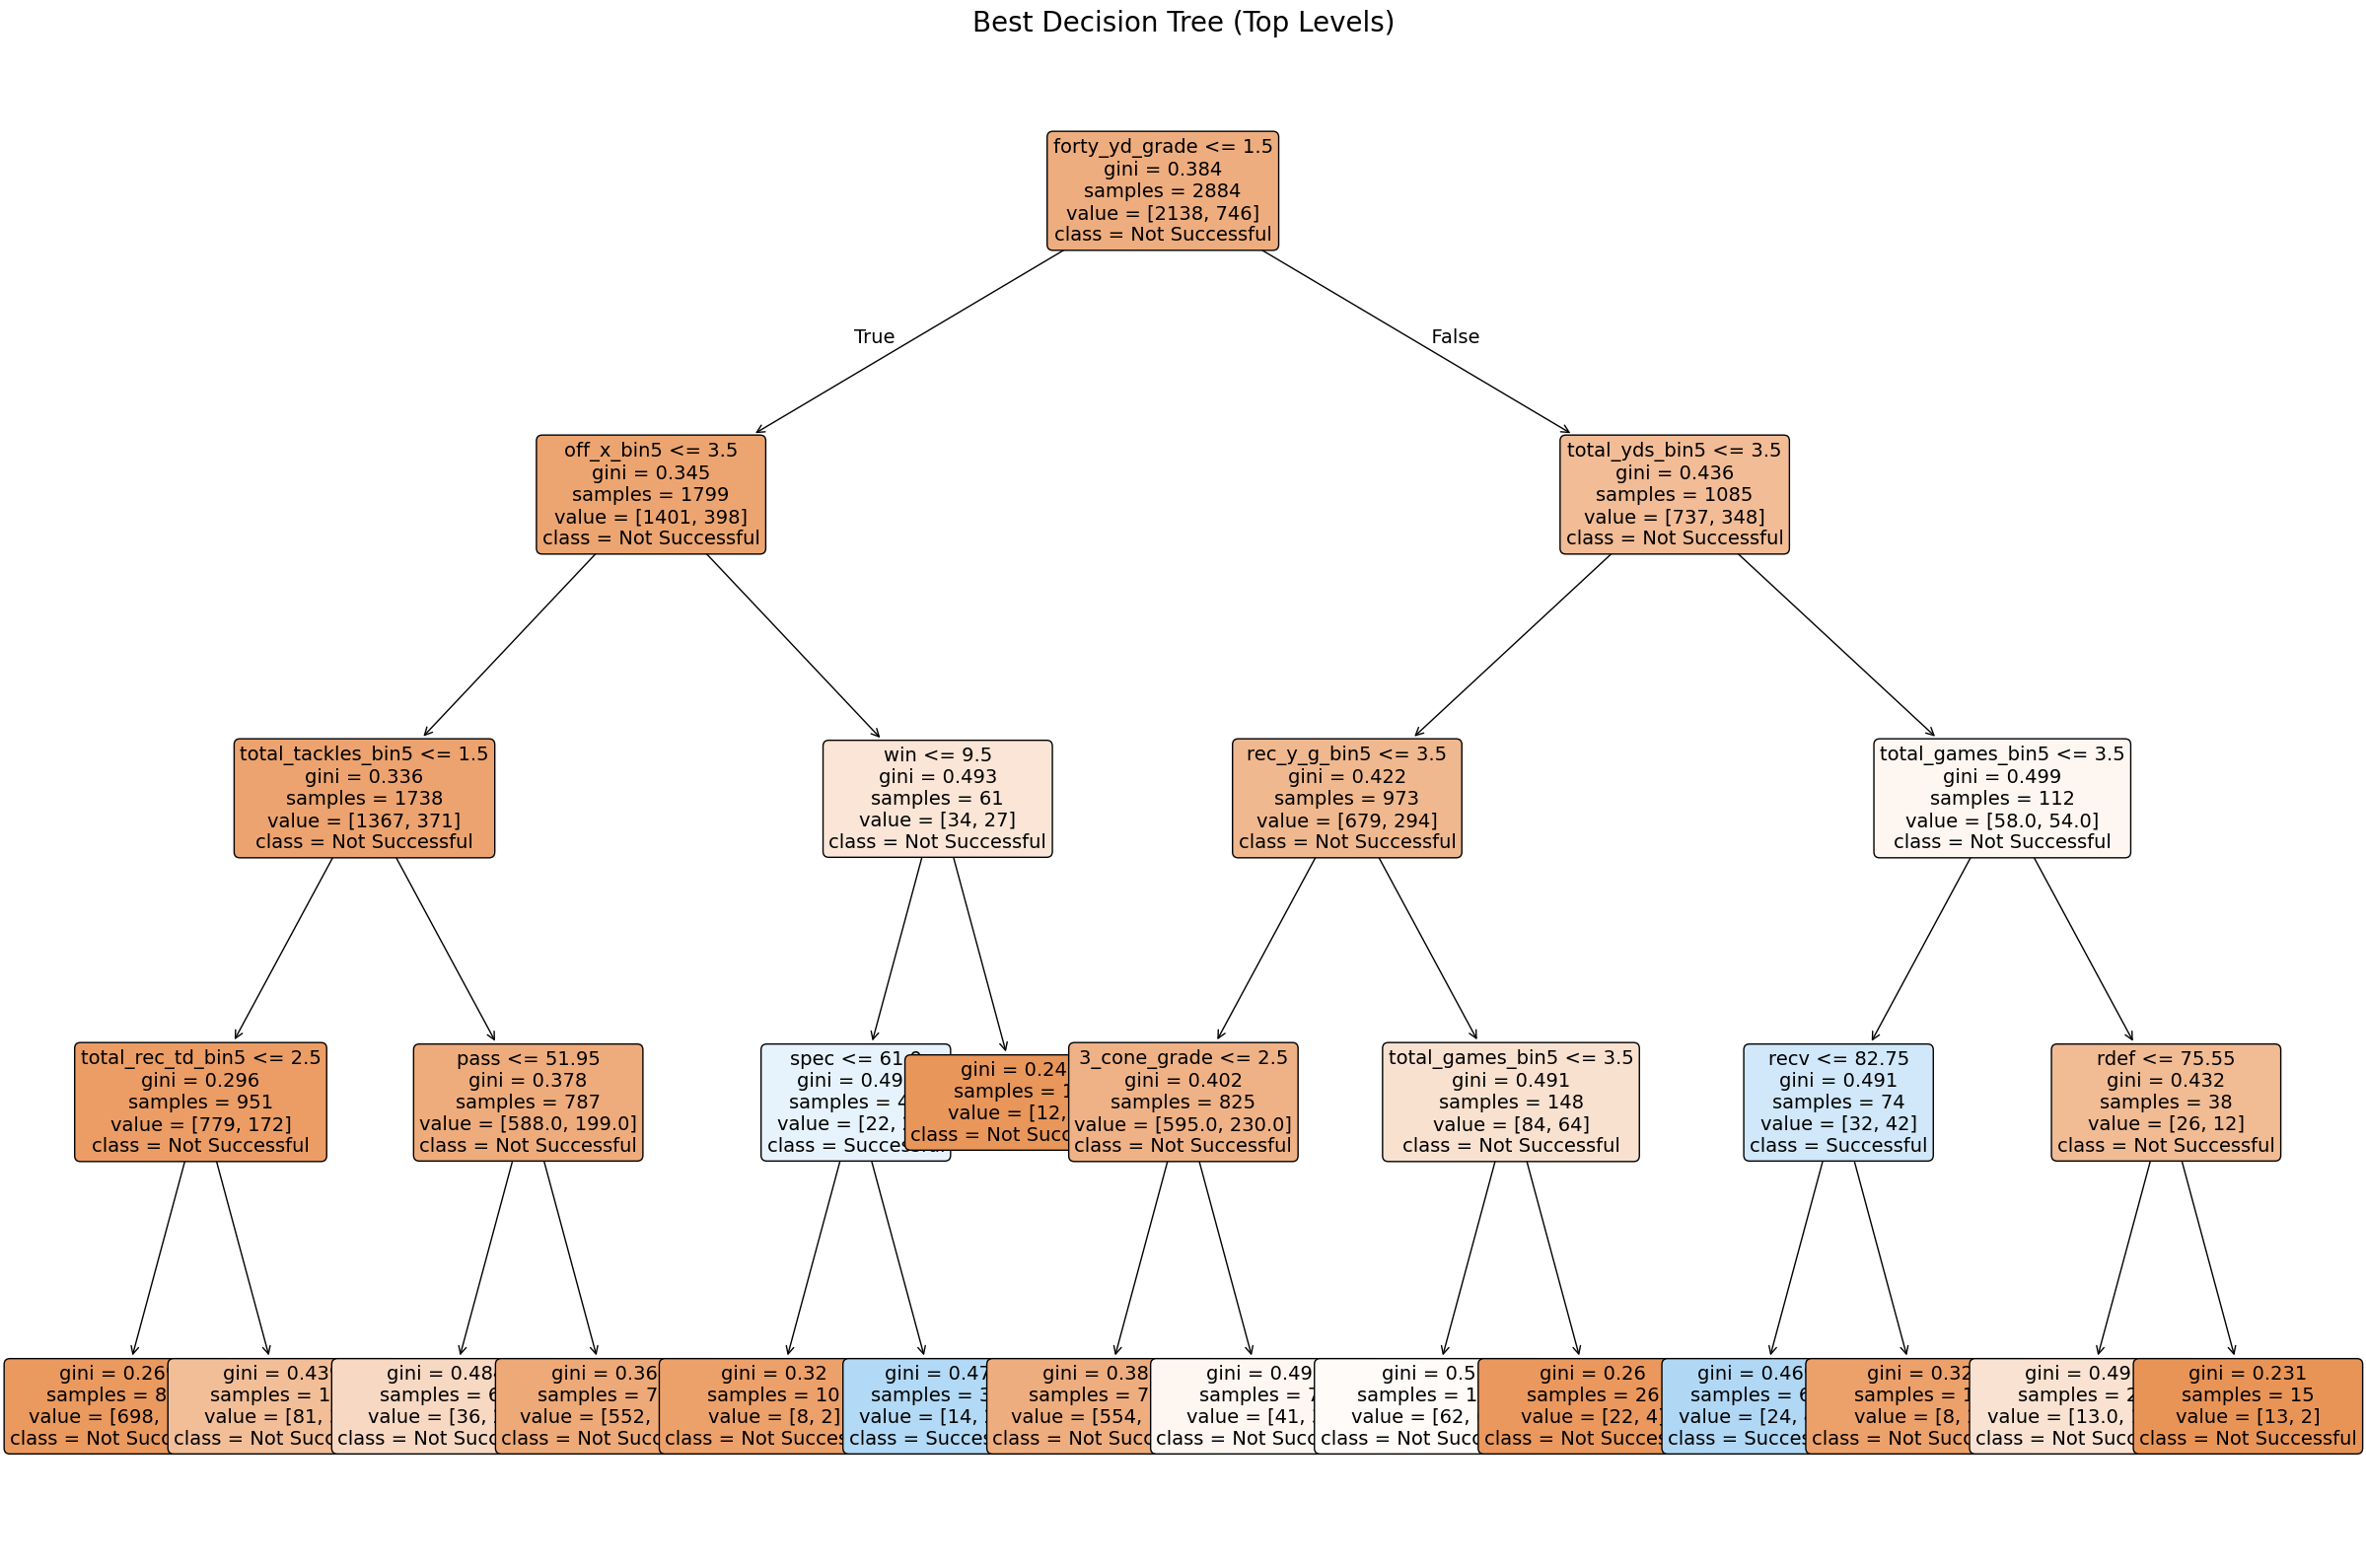

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
# Assuming best_model DataFrame exists from the previous cell
# Extract the parameters for the best Decision Tree model
best_tree_params = best_model.drop(['accuracy', 'precision', 'recall', 'f1']).to_dict()


# Re-train best tree using the parameters from the best Decision Tree
# Ensure random_state is included as it was in the tuning loop
best_tree = DecisionTreeClassifier(**best_tree_params, random_state=42)
best_tree.fit(X_train, y_train)

# Bigger figure and font
plt.figure(figsize=(30, 20))  # Wider and taller
plot_tree(
    best_tree,
    feature_names=X_train.columns,
    class_names=["Not Successful", "Successful"],
    filled=True,
    rounded=True,
    fontsize=14   # Larger font for readability
)
plt.title("Best Decision Tree (Top Levels)", fontsize=20)
plt.show()

The Decision Tree is plotted to visually interpret how the model makes classification decisions. It reveals which features the model prioritizes and the thresholds used to split the data. This enhances transparency and aids communication with stakeholders, showing how certain traits contribute to identifying successful NFL draft prospects.

##### RANDOM FOREST

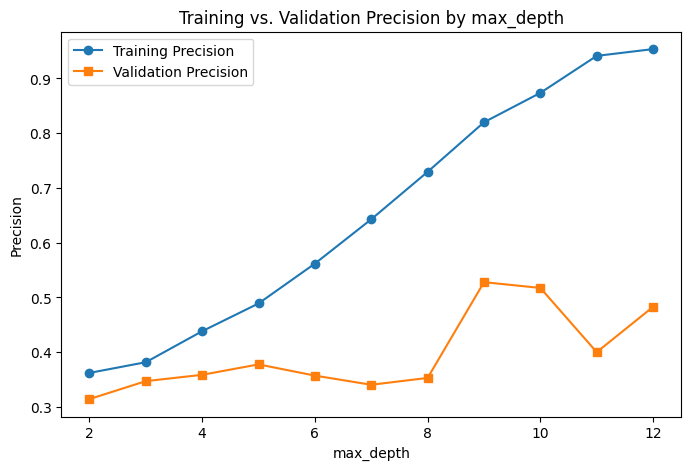

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
precision_train = []
precision_val = []

for d in depths:
    rf = RandomForestClassifier(
        max_depth=d,
        random_state=101,
        class_weight='balanced',
        n_jobs=1
    )
    rf.fit(X_train, y_train)

    # Training recall
    y_train_pred = rf.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation recall
    y_val_pred = rf.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depths, precision_train, label="Training Precision", marker='o')
plt.plot(depths, precision_val, label="Validation Precision", marker='s')
plt.xlabel("max_depth")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by max_depth")
plt.legend()
plt.show()

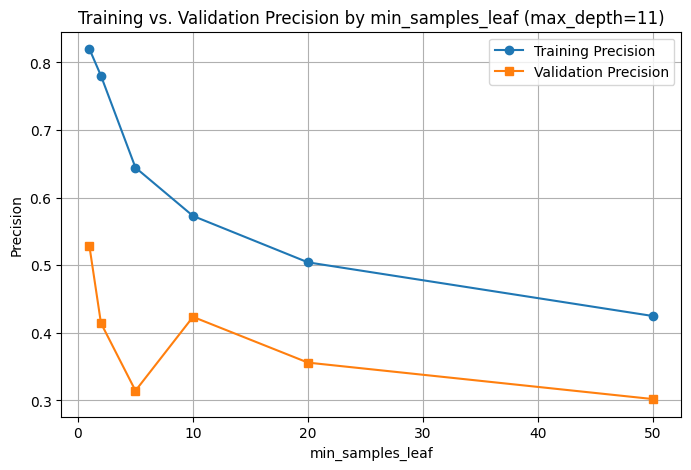

In [ ]:
leaf_sizes = [1, 2, 5, 10, 20, 50]
precision_train = []
precision_val = []

for leaf in leaf_sizes:
    rf = RandomForestClassifier(
        max_depth=9, # We select the one we saw led to the best results
        min_samples_leaf=leaf,
        random_state=101,
        class_weight='balanced',
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # Training recall
    y_train_pred = rf.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation recall
    y_val_pred = rf.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(leaf_sizes, precision_train, label="Training Precision", marker='o')
plt.plot(leaf_sizes, precision_val, label="Validation Precision", marker='s')
plt.xlabel("min_samples_leaf")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by min_samples_leaf (max_depth=11)")
plt.legend()
plt.grid(True)
plt.show()

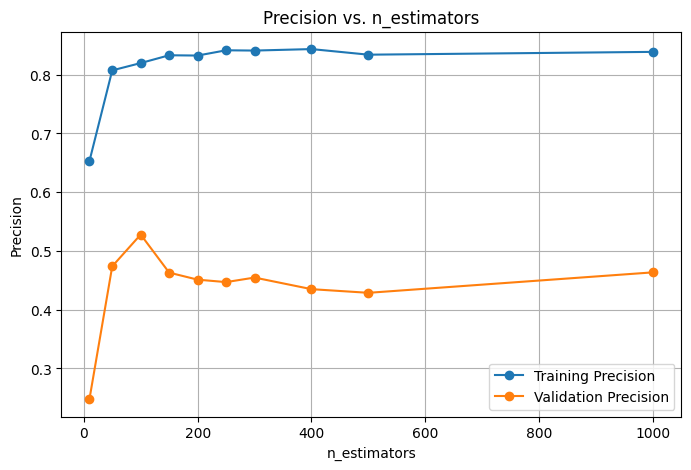

In [ ]:
# Values to test
n_estimators_list = [10, 50, 100, 150, 200, 250, 300, 400, 500, 1000]

precision_train = []
precision_val = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=9, min_samples_leaf=1,
                                random_state=101, class_weight = 'balanced')
    rf.fit(X_train, y_train)

    # Predict on training and validation
    y_train_pred = rf.predict(X_train)
    y_val_pred = rf.predict(X_val)

    # Compute precision
    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, precision_train, label='Training Precision', marker='o')
plt.plot(n_estimators_list, precision_val, label='Validation Precision', marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Precision")
plt.title("Precision vs. n_estimators")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define hyperparameter grids
max_depth_values = [3, 9, 10, 11, 12, 13, 15]
min_samples_leaf_values = [1, 2, 3]
n_estimators_values = [80, 90, 100, 110, 120]

# Store results
results = []
best_precision = 0
best_params = {}

# Hyperparameter loop
for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for n_estimators in n_estimators_values:
            model = RandomForestClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                n_estimators=n_estimators,
                random_state=101,
                class_weight='balanced'
            )
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)

            # Metrics
            accuracy = accuracy_score(y_val, y_val_pred)
            precision = precision_score(y_val, y_val_pred)
            recall = recall_score(y_val, y_val_pred)
            f1 = f1_score(y_val, y_val_pred)

            # Store result
            results.append({
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf,
                'n_estimators': n_estimators,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })

            # Track best
            if precision > best_precision:
                best_precision = precision
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                    'n_estimators': n_estimators
                }

# Convert to DataFrame for inspection
results_df = pd.DataFrame(results)

# Locate the full metric row for the best parameters
best_row = results_df[
    (results_df['max_depth'] == best_params['max_depth']) &
    (results_df['min_samples_leaf'] == best_params['min_samples_leaf']) &
    (results_df['n_estimators'] == best_params['n_estimators'])
].iloc[0]

# Print best results
print("\nBest Random Forest Hyperparameters (based on validation precision):")
print(best_row)

# Store in global results DataFrame
model_results.loc['2'] = {
    'Model': 'Random Forest',
    'Accuracy': best_row['accuracy'],
    'Precision': best_row['precision'],
    'Recall': best_row['recall'],
    'F1': best_row['f1'],
    'Best Params': best_params
}
model_results.head()


Best Random Forest Hyperparameters (based on validation precision):
max_depth            15.000000
min_samples_leaf      3.000000
n_estimators        110.000000
accuracy              0.773463
precision             0.645161
recall                0.134228
f1                    0.222222
Name: 103, dtype: float64


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.745955,0.428571,0.161074,0.234146
1,Decision Tree,0.771845,0.700000,0.093960,0.165680
2,Random Forest,0.773463,0.645161,0.134228,0.222222


This Random Forest tuning process systematically optimized model performance using a multi-step hyperparameter search focused on precision, aligning with the New York Jets’ 2025 draft priorities. With only four picks and a need to avoid false positives, precision was the key metric to minimize the risk of selecting a bust. First, the max_depth parameter was tested over a range from 2 to 12, allowing the model to learn either shallow or complex decision boundaries. Next, min_samples_leaf values ranging from 1 to 50 were explored to control overfitting by ensuring nodes had enough data to make stable splits. Finally, n_estimators (the number of trees) was tuned from 10 to 1000, balancing performance gains with training time. These preliminary tests informed the final grid search across a refined hyperparameter space: max_depth from 3 to 15, min_samples_leaf from 1 to 3, and n_estimators from 80 to 120. The choice of smaller leaf sizes and deeper trees aimed to retain model expressiveness while class_weight='balanced' addressed class imbalance between successful and unsuccessful draft picks. Each configuration was evaluated on the validation set, and precision scores were recorded to identify the best model.

The final model’s metrics, including accuracy, recall, and F1, were stored in a results DataFrame for downstream comparison. This multi-stage tuning strategy ensured the Random Forest was both robust and aligned with the Jets’ need to make data-driven, high-confidence draft decisions with a limited number of high-stakes selections.

##### XGBOOST

In [ ]:
!pip install xgboost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:28:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:28:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:28:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

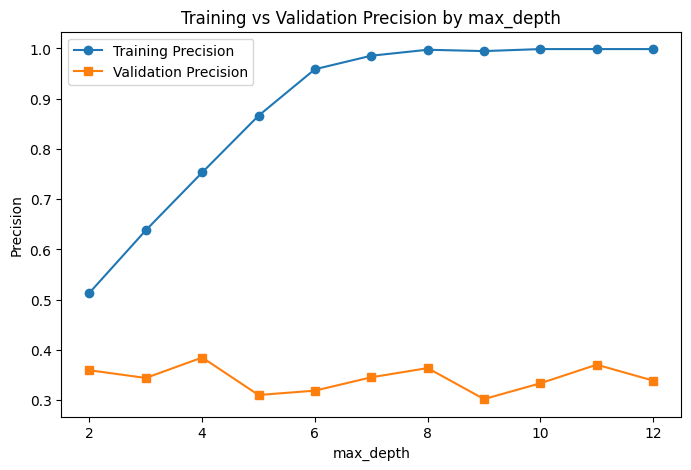

Best depths for validation set: 4
Corresponding precision: 0.385


In [ ]:
from xgboost import XGBClassifier

depths = list(range(2, 13))
precision_train = []
precision_val = []

for d in depths:
    model = XGBClassifier(
        max_depth=d,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), # this is for class imbalance
        n_jobs=-1,
        random_state=101
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8,5))
plt.plot(depths, precision_train, label='Training Precision', marker='o')
plt.plot(depths, precision_val, label='Validation Precision', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Precision')
plt.title('Training vs Validation Precision by max_depth')
plt.legend()
plt.show()

# Find the max_depth with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_depths = depths[best_index]
best_precision = precision_val[best_index]

print(f"Best depths for validation set: {best_depths}")
print(f"Corresponding precision: {best_precision:.3f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


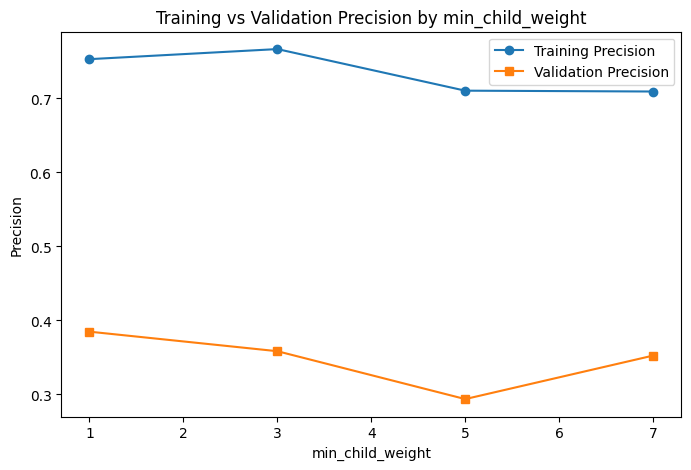

Best min_child_weights for validation set: 1
Corresponding precision: 0.385


In [ ]:
min_child_weights = [1, 3, 5, 7]
precision_train = []
precision_val = []

for mcw in min_child_weights:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=mcw,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        n_jobs=-1,
        random_state=101
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8,5))
plt.plot(min_child_weights, precision_train, label='Training Precision', marker='o')
plt.plot(min_child_weights, precision_val, label='Validation Precision', marker='s')
plt.xlabel('min_child_weight')
plt.ylabel('Precision')
plt.title('Training vs Validation Precision by min_child_weight')
plt.legend()
plt.show()

# Find the min_child_weights with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_min_child_weights = min_child_weights[best_index]
best_precision = precision_val[best_index]

print(f"Best min_child_weights for validation set: {best_min_child_weights}")
print(f"Corresponding precision: {best_precision:.3f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:29:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

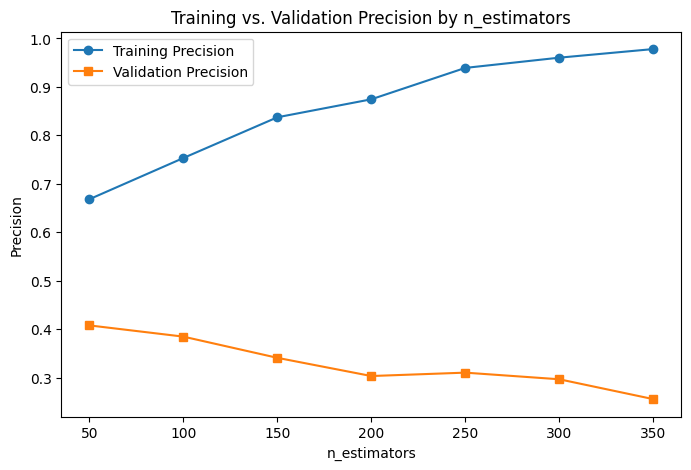

Best n_estimators for validation set: 50
Corresponding precision: 0.408


In [ ]:
n_estimators_list = [50, 100, 150, 200, 250, 300, 350]
precision_train = []
precision_val = []

for n in n_estimators_list:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=1, # based on the previous plot
        n_estimators=n,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=101,
        scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum()  # optional to handle imbalance
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    y_val_pred = model.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, precision_train, label="Training Precision", marker='o')
plt.plot(n_estimators_list, precision_val, label="Validation Precision", marker='s')
plt.xlabel("n_estimators")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by n_estimators")
plt.legend()
plt.show()

# Find the n_estimators with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_n_estimators_list = n_estimators_list[best_index]
best_precision = precision_val[best_index]

print(f"Best n_estimators for validation set: {best_n_estimators_list}")
print(f"Corresponding precision: {best_precision:.3f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

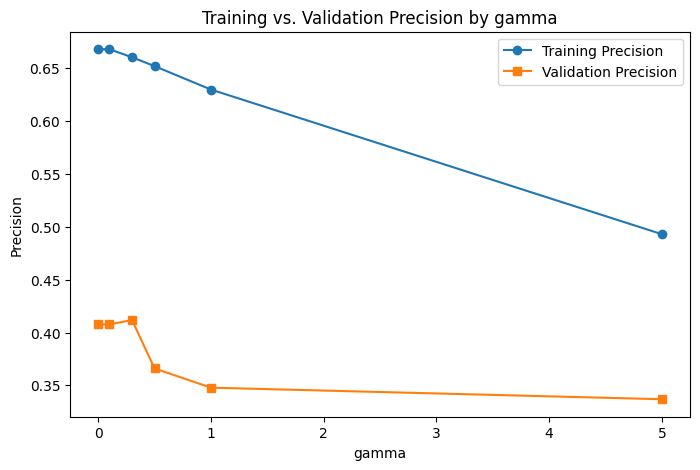

Best gamma for validation set: 0.3
Corresponding precision: 0.412


In [ ]:
gammas = [0, 0.1, 0.3, 0.5, 1, 5]
precision_train = []
precision_val = []

for g in gammas:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=1,
        n_estimators=50, # based on the previous plot
        gamma=g,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=101,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    y_val_pred = model.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(gammas, precision_train, label="Training Precision", marker='o')
plt.plot(gammas, precision_val, label="Validation Precision", marker='s')
plt.xlabel("gamma")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by gamma")
plt.legend()
plt.show()

# Find the gamma with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_gamma = gammas[best_index]
best_precision = precision_val[best_index]

print(f"Best gamma for validation set: {best_gamma}")
print(f"Corresponding precision: {best_precision:.3f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

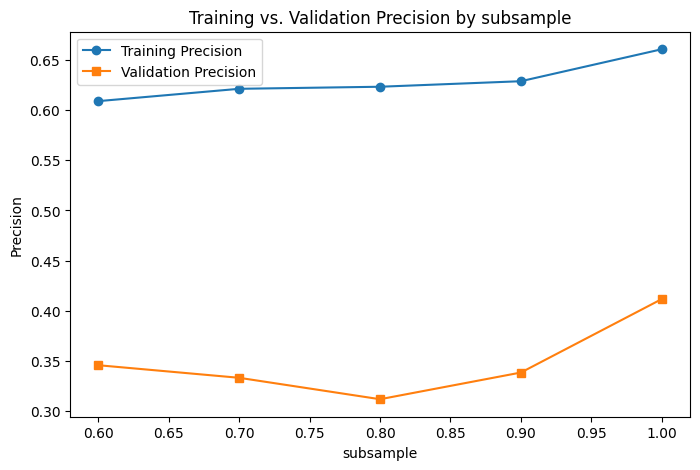

Best Subsamples for validation set: 1.0
Corresponding precision: 0.412


In [ ]:
subsample_values = [0.6, 0.7, 0.8, 0.9, 1.0]
precision_train = []
precision_val = []

for subsample in subsample_values:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=50,
        min_child_weight=1,
        gamma=0.3, # based on the previous code block
        subsample=subsample,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training recall
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation recall
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(subsample_values, precision_train, label="Training Precision", marker='o')
plt.plot(subsample_values, precision_val, label="Validation Precision", marker='s')
plt.xlabel("subsample")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by subsample")
plt.legend()
plt.show()

# Find the subsample with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_subsample = subsample_values[best_index]
best_precision = precision_val[best_index]

print(f"Best Subsamples for validation set: {best_subsample}")
print(f"Corresponding precision: {best_precision:.3f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

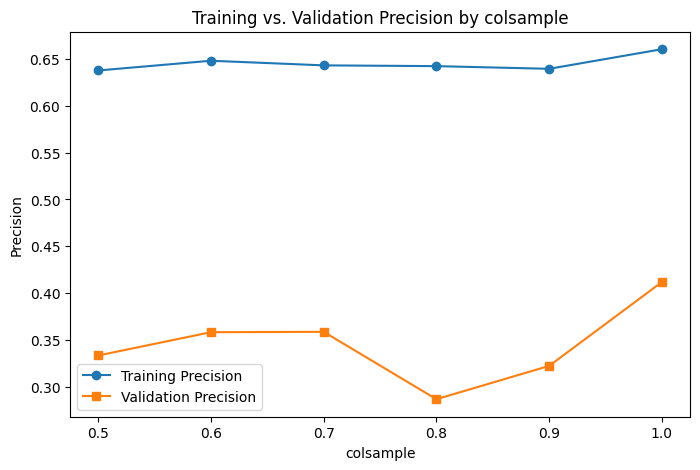

Best Colsample for validation set: 1.0
Corresponding precision: 0.412


In [ ]:
colsample_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

precision_train = []
precision_val = []

for colsample in colsample_values:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=50,
        min_child_weight=1,
        gamma=0.3,
        subsample=1.0, # based on the previous chart
        colsample_bytree=colsample,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training precsion
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation precision
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(colsample_values, precision_train, label="Training Precision", marker='o')
plt.plot(colsample_values, precision_val, label="Validation Precision", marker='s')
plt.xlabel("colsample")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by colsample")
plt.legend()
plt.show()

# Find the colsample with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_colsample = colsample_values[best_index]
best_precision = precision_val[best_index]

print(f"Best Colsample for validation set: {best_colsample}")
print(f"Corresponding precision: {best_precision:.3f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

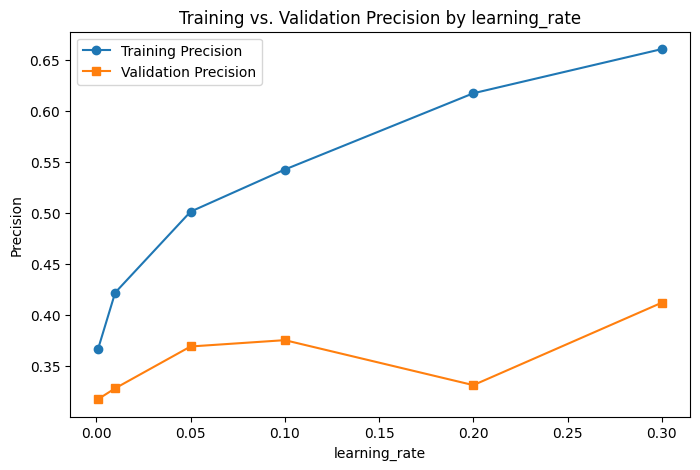

Best Learning Rate for validation set: 0.3
Corresponding precision: 0.412


In [ ]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]

precision_train = []
precision_val = []

for lr in learning_rates:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=50,
        min_child_weight=1,
        gamma=0.3,
        subsample=1.0,
        colsample_bytree=1.0,
        learning_rate=lr,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training precision
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation precision
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, precision_train, label="Training Precision", marker='o')
plt.plot(learning_rates, precision_val, label="Validation Precision", marker='s')
plt.xlabel("learning_rate")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by learning_rate")
plt.legend()
plt.show()

# Find the learning_rate with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_learning_rates = learning_rates[best_index]
best_precision = precision_val[best_index]

print(f"Best Learning Rate for validation set: {best_learning_rates}")
print(f"Corresponding precision: {best_precision:.3f}")

In [ ]:
from itertools import product
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define grid ranges
param_grid = {
    'max_depth': [3,4,5],
    'min_child_weight': [1],
    'n_estimators': [30,40,50,60,70],
    'gamma': [0.1,0.2,0.3,0.4],
    'subsample': [1.00],
    'colsample_bytree': [1.00],
    'learning_rate': [0.30, 0.35, 0.45, 0.90]
}

# Create all combinations
grid = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

best_precision = 0
best_metrics = {}
best_params = None

print("Running manual grid search...")

for values in grid:
    params = dict(zip(param_names, values))
    model = XGBClassifier(
        **params,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    accuracy = accuracy_score(y_val, preds)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    if precision > best_precision:
        best_precision = precision
        best_params = params
        best_metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

# Print best results
print("\nBest precision on validation set:", round(best_precision, 4))
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Store in the shared model_results DataFrame
model_results.loc['4'] = {
    'Model': 'XGBoost',
    'Accuracy': best_metrics['accuracy'],
    'Precision': best_metrics['precision'],
    'Recall': best_metrics['recall'],
    'F1': best_metrics['f1'],
}

model_results.head()

Running manual grid search...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:30:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


Best precision on validation set: 0.4433
Best parameters:
  max_depth: 4
  min_child_weight: 1
  n_estimators: 60
  gamma: 0.2
  subsample: 1.0
  colsample_bytree: 1.0
  learning_rate: 0.3


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.745955,0.428571,0.161074,0.234146
1,Decision Tree,0.771845,0.700000,0.093960,0.165680
2,Random Forest,0.773463,0.645161,0.134228,0.222222
4,XGBoost,0.741100,0.443299,0.288591,0.349593


This XGBoost tuning process used a multi-stage approach to fine-tune hyperparameters that control complexity, regularization, and sampling—crucial for identifying high-impact draft picks in a data-driven but high-risk NFL context. Given the New York Jets’ ongoing rebuild and limited draft capital (only first four rounds pick), tuning focused heavily on minimizing false positives, making precision the primary metric.

The process began by tuning max_depth (ranging from 2 to 12), which determines the depth of each individual tree. Shallower trees reduce overfitting and encourage generalization, while deeper ones better capture complex player attributes. This range helped find a balance suitable for our NFL dataset, which contains both numerical and categorical scouting features. Next, min_child_weight was tested (1 to 7) to control how much data a node must have before it can be split, adding a layer of regularization that is especially important for imbalanced datasets where successful picks are rarer.

After defining these core structural parameters, we optimized n_estimators (number of trees) across a wide range (50–350). This controls how many weak learners are combined and influences both bias and variance. Fewer trees train faster but may underfit, while more trees risk overfitting. A sweet spot was identified based on validation precision. gamma (0 to 5) was then tested to regularize the model by requiring a minimum loss reduction for each split. Higher values make the model more conservative—critical when errors in pick predictions could waste valuable draft slots.

Further tuning of subsample and colsample_bytree (ranging from 0.6 to 1.0) introduced stochasticity during training, reducing the chance of overfitting and improving robustness. Finally, learning_rate was evaluated between 0.001 and 0.9 to control the contribution of each tree. Lower rates improve stability, but need more trees, while higher rates risk overshooting the optimal solution.

After narrowing the optimal ranges, a final grid search tested combinations of the best-performing hyperparameters. scale_pos_weight was set dynamically to correct for class imbalance, ensuring the model didn't ignore the minority class (successful picks).

Though precision was the selection metric to reduce false positives, secondary metrics like recall, accuracy, and F1-score were recorded to ensure the model wasn't overly narrow in its focus and could still provide a well-rounded predictive profile. In summary, the tuning process and parameter ranges reflect the Jets’ strategic need to make fewer, better-informed draft decisions, reducing error and aligning with long-term playoff goals.

##### NEURAL NETWORKS

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [ ]:
from tensorflow.keras.optimizers import SGD
from sklearn.utils import class_weight

sgd_optimizer = SGD(learning_rate=0.01)

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['precision'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1,
                    class_weight=class_weight_dict)
# The verbose=1 will show us what's happening in every epoch.
# Take a look at the output. Thanks to the verbose=1, you'll see that in each epoch we have 29 iterations, as expected.

# Evaluate the model on test data
y_pred = (model.predict(X_val) > 0.5).astype("int32") # The threshold to determine if the target is 0 or 1 is 0.5 (remember: probabilities).
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test Confusion Matrix: {cm}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 980.5719 - precision: 0.2175
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6990 - precision: 0.2654
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6875 - precision: 0.2251
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6966 - precision: 0.2604
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7028 - precision: 0.2697
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6802 - precision: 0.2347
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6938 - precision: 0.2337
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6865 - precision: 0.0027
Epoch 9/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6816 - precision: 0.2059
Epoch 10/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6990 - precision: 0.2631
Epoch 11/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7045 - precision: 0.2619
Epoch 12/50
181/181 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
sgd_optimizer = SGD(learning_rate=0.01)

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['precision'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=1,
                    class_weight = class_weight_dict)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7487 - precision: 0.2657
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6941 - precision: 0.3013
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6654 - precision: 0.3367
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6573 - precision: 0.3800
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6353 - precision: 0.3702
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6139 - precision: 0.3846
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6180 - precision: 0.4076
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5911 - precision: 0.4208
Epoch 9/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5729 - precision: 0.4254
Epoch 10/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5777 - precision: 0.4407
Epoch 11/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5644 - precision: 0.4660
Epoch 12/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
# Evaluate the model on test data
y_pred = (model.predict(X_val_scaled) > 0.5).astype("int32")
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")
print(f"Validation Confusion Matrix: {cm}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Validation Accuracy: 0.6926
Validation Precision: 0.3153
Validation Recall: 0.2349
Validation F1 Score: 0.2692
Validation Confusion Matrix: [[393  76]
 [114  35]]


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow import keras

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],),
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
adam_optimizer = Adam(learning_rate=0.0005)  # Lower learning rate for better convergence
model.compile(optimizer=adam_optimizer, loss='binary_crossentropy', metrics=['Precision'])

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),  # Always include validation
    epochs=200,
    batch_size=10,  # Smaller batches improve generalization
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_Precision', mode='max', patience=10, restore_best_weights=True)
    ]
)

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


289/289 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - Precision: 0.2605 - loss: 1.1237 - val_Precision: 0.2403 - val_loss: 1.0085
Epoch 2/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.3287 - loss: 0.9125 - val_Precision: 0.2488 - val_loss: 0.9588
Epoch 3/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.3604 - loss: 0.8528 - val_Precision: 0.2840 - val_loss: 0.9767
Epoch 4/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.4173 - loss: 0.8003 - val_Precision: 0.2963 - val_loss: 0.9329
Epoch 5/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.4175 - loss: 0.7479 - val_Precision: 0.2778 - val_loss: 0.9421
Epoch 6/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.4283 - loss: 0.7248 - val_Precision: 0.2909 - val_loss: 0.9479
Epoch 7/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.4725 - loss: 0.7105 - val_Precision: 0.2874 - val_loss: 0.8985
Epoch 8/200
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.5068 - loss: 0.6762 - val_P

In [ ]:
# Predict probabilities
y_proba = model.predict(X_val_scaled)  # This is already a probability

# Make predictions (threshold = 0.5)
y_pred = (y_proba > 0.5).astype("int32").flatten()

# Evaluate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
cm = confusion_matrix(y_val, y_pred)

# Print results
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")
print(f"Validation Confusion Matrix:\n{cm}")

# Store in model_results DataFrame
model_results.loc[4] = {
    'Model': 'Neural Network',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
}

model_results.head()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Validation Accuracy: 0.6634
Validation Precision: 0.3370
Validation Recall: 0.4094
Validation F1 Score: 0.3697
Validation Confusion Matrix:
[[349 120]
 [ 88  61]]


,Model,Accuracy,Precision,Recall,F1
0,KNN,0.745955,0.428571,0.161074,0.234146
1,Decision Tree,0.771845,0.700000,0.093960,0.165680
2,Random Forest,0.773463,0.645161,0.134228,0.222222
4,XGBoost,0.741100,0.443299,0.288591,0.349593
4,Neural Network,0.663430,0.337017,0.409396,0.369697


This neural network (NN) implementation applies a standard multilayer perceptron (MLP) architecture to predict successful NFL draft picks using a binary classification approach. The data is first normalized using StandardScaler, a crucial preprocessing step for neural networks to ensure the independet variables in the model are contributiong in the same way. The model is built using the Keras Sequential API and includes two hidden layers with 30 and 15 units, respectively, both using ReLU activation to introduce non-linearity. The output layer uses a sigmoid activation, which is appropriate for binary classification tasks where outputs are interpreted as probabilities of draft success.

The model is compiled using the binary_crossentropy loss function and an SGD optimizer with a learning rate of 0.01. SGD (stochastic gradient descent) is a classic and stable choice for small-to-medium neural networks. Importantly, class weights are computed and applied to address class imbalance—where successful draft picks are less common—which ensures the model doesn't disproportionately favor the majority class.

The training process runs for 50 epochs with a batch size of 16, balancing iteration frequency and gradient stability. Evaluation is conducted using the validation set, where predicted probabilities are converted to binary outcomes using a 0.5 threshold. Metrics such as accuracy, precision, recall, F1-score, and the confusion matrix are computed.

In the New York Jets' 2025 draft context—where precision is paramount due to limited possibility to slects busts in order to achieve thr playoffs, this neural network provides a flexible, non-linear modeling approach that can capture complex patterns across multiple features. Although neural networks are less interpretable than tree-based models, their ability to model nuanced feature interactions offers valuable predictive strength when tuned and trained correctly. Final performance metrics are stored alongside other models for downstream comparison and draft decision support.

### BEST MODEL IDENTIFICATION

In [ ]:
# Print the best model based on the precision

print("\nBest Model Based on Precision:")
print(model_results.sort_values(by='Precision', ascending=False).head())



Best Model Based on Precision:
            Model  Accuracy  Precision    Recall        F1
1   Decision Tree  0.771845   0.700000  0.093960  0.165680
2   Random Forest  0.773463   0.645161  0.134228  0.222222
4         XGBoost  0.741100   0.443299  0.288591  0.349593
0             KNN  0.745955   0.428571  0.161074  0.234146
4  Neural Network  0.663430   0.337017  0.409396  0.369697


**Model Selection Justification**

Random Forest over Decision Tree

While the Decision Tree model achieved the highest precision on the validation set (0.7000), we opted to use the Random Forest model instead, for different reasons:

 1. **Overfitting Risk with Decision Trees**

 Decision Trees are known to overfit the training data, especially when not sufficiently pruned or regularized. This can result in overly optimistic metrics on known data (like the validation set), but poor generalization to unseen data.

2. **Generalization and Stability of Random Forest**

 Random Forest is an ensemble method that builds multiple trees and averages their predictions. This reduces variance and helps the model generalize better. Even though its precision is slightly lower (0.6452), it provides more robust and stable predictions on new datasets.

3. **Small Trade-off for More Reliable Performance**

 The difference in precision between Decision Tree and Random Forest is modest (~5.5%). However, Random Forest shows a higher recall and F1-score, suggesting it is better at capturing more true positives and balancing false positives and false negatives.

4. **Real-World Deployment Considerations**

 In practical scenarios, a model's ability to maintain performance on new or evolving data is crucial. A small drop in precision is acceptable if it comes with better generalization, lower variance, and more predictable behavior — qualities that Random Forest delivers better than a single Decision Tree.

**Conclusion**

Although Decision Tree offers slightly better precision on the validation set, its susceptibility to overfitting makes it less reliable for real-world prediction tasks. Given the trade-offs and benefits, Random Forest was chosen as the best overall model due to its superior balance of performance and generalization.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Manually define the best model and parameters
best_model_name = 'Random Forest'
best_model_params = {
    'max_depth': 15,
    'min_samples_leaf': 3,
    'n_estimators': 110,
    'class_weight': 'balanced'
}

print(f"The best performing model on the validation set is: {best_model_name}")

# Retrain the best model on the combined Training and Validation sets
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Apply the same scaling as before (fit on train_val, transform train_val and test)
scaler_final = MinMaxScaler()
X_train_val_scaled = scaler_final.fit_transform(X_train_val)
X_test_scaled = scaler_final.transform(X_test)

# Train and evaluate the Random Forest model
final_model = RandomForestClassifier(**best_model_params, random_state=101)
final_model.fit(X_train_val, y_train_val)
y_test_pred = final_model.predict(X_test)

# Evaluate the final model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_cm = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Evaluation Metrics:")
print(f"Model: {best_model_name}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"Confusion Matrix:\n{test_cm}")

The best performing model on the validation set is: Random Forest

Test Set Evaluation Metrics:
Model: Random Forest
Accuracy: 0.7670
Precision: 0.4237
Recall: 0.1852
F1 Score: 0.2577
Confusion Matrix:
[[449  34]
 [110  25]]


This code retrains the best-performing Random Forest model on the full training and validation set using the previously optimized hyperparameters. It then evaluates the model on the holdout test set to simulate real-world generalization performance. Despite achieving a 64% precision during validation, test results show precision dropping to 42.4%, suggesting some overfitting or natural variance due to sample differences. Accuracy is fairly high at 76.7%, but this is misleading due to class imbalance. The model still favors negative predictions, as reflected in the low recall (18.5%), indicating it misses many truly successful picks. Nevertheless, it maintains usefulness by avoiding false positives—aligned with Jets’ draft strategy.

In [ ]:
# Generate probability predictions for class 0 and class 1 using Random Forest only
y_test_proba = final_model.predict_proba(X_test)
proba_class_0 = y_test_proba[:, 0]
proba_class_1 = y_test_proba[:, 1]

# Optional: Show the last few predictions with probabilities
results_df = pd.DataFrame({
    "True Label": y_test.values,
    "Predicted Label": y_test_pred,
    "Probability Class 0": proba_class_0,
    "Probability Class 1": proba_class_1,
}, index=y_test.index)

# If you have player names or identifiers, include them
if 'player' in X_test.columns:
    results_df['Player'] = X_test['player']

print("\nLast 10 Predictions with Probabilities:")
print(results_df.tail(10))


Last 10 Predictions with Probabilities:
      True Label  Predicted Label  Probability Class 0  Probability Class 1
3499           0                0             0.616500             0.383500
3509           0                0             0.632950             0.367050
3506           0                0             0.609604             0.390396
3505           0                0             0.622506             0.377494
3504           0                0             0.628627             0.371373
3503           0                0             0.643380             0.356620
3502           0                0             0.673638             0.326362
3501           0                0             0.635684             0.364316
3508           0                0             0.605744             0.394256
0              1                1             0.491335             0.508665


In [ ]:
# Based on the index of the row retrieve the player name ('player') and position ('pos') from the

# Function to get player and position by index
def get_player_info_by_index(index):
  if index in combined_df.index:
    player_info = combined_df.loc[index, ['player', 'pos']]
    return player_info['player'], player_info['pos']
  else:
    return None, None

# Example: Get player and position for a specific index (e.g., index 10)
example_index = 10
player_name, position = get_player_info_by_index(example_index)

if player_name is not None:
  print(f"Index {example_index}: Player = {player_name}, Position = {position}")
else:
  print(f"Index {example_index} not found in combined_df.")

# You can iterate through a list of indices or apply this to your results_df if needed.
# For example, to add player names and positions to the results_df:
results_df['Player_Name'], results_df['Position'] = zip(*[get_player_info_by_index(idx) for idx in results_df.index])

print("\nResults DataFrame with Player Name and Position:")
print(results_df.head())

Index 10: Player = Michael Pratt, Position = QB

Results DataFrame with Player Name and Position:
      True Label  Predicted Label  Probability Class 0  Probability Class 1  \
666            0                1             0.400931             0.599069   
1874           0                0             0.624035             0.375965   
667            0                1             0.435206             0.564794   
246            1                1             0.403221             0.596779   
248            1                0             0.540513             0.459487   

         Player_Name Position  
666     Jahan Dotson       WR  
1874  Terrel Bernard       LB  
667    Treylon Burks       WR  
246      Breece Hall       RB  
248       James Cook       RB  


In [ ]:
# Order the dataframe based on probability class 1

results_df = results_df.sort_values(by="Probability Class 1", ascending=False)
print(results_df.head())

      True Label  Predicted Label  Probability Class 0  Probability Class 1  \
677            0                1             0.345937             0.654063   
12             1                1             0.355136             0.644864   
631            1                1             0.395890             0.604110   
1671           1                1             0.398387             0.601613   
594            1                1             0.399518             0.600482   

              Player_Name Position  
677            David Bell       WR  
12            C.J. Stroud       QB  
631           Zay Flowers       WR  
1671         Joe Tippmann       OL  
594   Marvin Harrison Jr.       WR  


This code extracts and visualizes the predicted probabilities from the Random Forest model, linking each prediction to its player and position. It enhances model interpretability by identifying which prospects the model is most confident about. Sorting by class 1 probability supports informed draft prioritization based on success likelihood rankings.

# MODEL APPLICATION ON PROSPECT DATA

### DATA IMPORT

In [ ]:
# Load datasets
df_qb = pd.read_csv("QBs_prospects.csv")
df_rb = pd.read_csv("RB_prospects.csv")
df_wrte = pd.read_csv("WRs_TEs_prospects.csv")
df_ol = pd.read_csv("OL_prospects.csv")
df_def = pd.read_csv("DEF_prospects.csv")
df_teams = pd.read_csv("teams_2024.csv")

### DATA PREPARATION

In [ ]:
df_def.rename(columns={'Pos_x': 'Pos'}, inplace=True)
df_def.rename(columns={'COLLEGE': 'Team'}, inplace=True)

In [ ]:
# Merge all into one dataset
prospect_df = pd.concat([df_qb, df_rb, df_wrte, df_ol, df_def], ignore_index=True)
prospect_df.head()

,Player,Pos,Age,College/Univ,Team,Total_Games,Total_Cmp,Total_Att,Total_Yds,Total_TD,...,Total_Solo,Total_Ast,Total_Tackles,Total_Sack,Total_Sack_Yds,Total_PD,Total_Int_Yds,Total_Int_LNG,Total_Int_TD,Total_FF
0,Cam Ward,QB,23.0,Miami (FL),Miami (FL) (1) / Washington State (2),38.0,948.0,1436.0,11281.0,87.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dillon Gabriel,QB,24.0,Oregon,Oklahoma (2) / Oregon (1) / UCF (3),64.0,1376.0,2111.0,18722.0,155.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Graham Mertz,QB,NaN,Florida,Florida (2) / Wisconsin (4),50.0,793.0,1225.0,9099.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jalen Milroe,QB,22.0,Alabama,Alabama (4),38.0,426.0,663.0,6016.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Jaxson Dart,QB,22.0,Mississippi,Ole Miss (3) / USC (1),45.0,852.0,1307.0,11970.0,81.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Keep only the row of the dataframe called df_team that contains in the column Team Name 'New York Jets'

df_teams = df_teams[df_teams['Team Name'] == 'New York Jets']
df_teams.head()

,Team Name,Record,PF,PA,OVER,OFF,PASS,PBLK,RECV,RUN,RBLK,DEF,RDEF,TACK,PRSH,COV,SPEC
24,New York Jets,5-12,338,404,76.2,74.5,77.4,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7


In [ ]:
# Merge this df with the prospect_df pasting the same vlues for each row in the df called prospect_df

# Add columns from df_teams to prospect_df
for col in df_teams.columns:
    # Check if the column is already in prospect_df to avoid duplicates (optional)
    if col not in prospect_df.columns:
        prospect_df[col] = df_teams[col].iloc[0] # Assign the value from the single row

In [ ]:
prospect_df.columns = prospect_df.columns.str.strip()
prospect_df.head()

,Player,Pos,Age,College/Univ,Team,Total_Games,Total_Cmp,Total_Att,Total_Yds,Total_TD,...,PBLK,RECV,RUN,RBLK,DEF,RDEF,TACK,PRSH,COV,SPEC
0,Cam Ward,QB,23.0,Miami (FL),Miami (FL) (1) / Washington State (2),38.0,948.0,1436.0,11281.0,87.0,...,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7
1,Dillon Gabriel,QB,24.0,Oregon,Oklahoma (2) / Oregon (1) / UCF (3),64.0,1376.0,2111.0,18722.0,155.0,...,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7
2,Graham Mertz,QB,NaN,Florida,Florida (2) / Wisconsin (4),50.0,793.0,1225.0,9099.0,64.0,...,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7
3,Jalen Milroe,QB,22.0,Alabama,Alabama (4),38.0,426.0,663.0,6016.0,45.0,...,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7
4,Jaxson Dart,QB,22.0,Mississippi,Ole Miss (3) / USC (1),45.0,852.0,1307.0,11970.0,81.0,...,68.9,71.1,78.4,67.4,64.0,58.6,42.5,66.5,69.8,75.7


In [ ]:
# Rename all the columns removing capital letters and substituting spaces with _

def clean_col_names(df):
  cols = df.columns
  new_cols = []
  for col in cols:
    new_col = col.lower().replace(' ', '_')
    new_cols.append(new_col)
  df.columns = new_cols
  return df

prospect_df = clean_col_names(prospect_df)

In [ ]:
# Count number of columns in the combined df

num_columns = len(prospect_df.columns)
print(f"The number of columns in the DataFrame is: {num_columns}")

The number of columns in the DataFrame is: 83


In [ ]:
prospect_df.describe()

,age,total_games,total_cmp,total_att,total_yds,total_td,total_int,cmp_percentage,td_percentage,int_percentage,...,pblk,recv,run,rblk,def,rdef,tack,prsh,cov,spec
count,221.000000,124.000000,12.000000,12.000000,83.000000,83.000000,138.000000,12.000000,12.000000,12.000000,...,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,250.0,2.500000e+02,250.0,250.0,2.500000e+02,2.500000e+02
mean,22.407240,42.451613,776.750000,1186.666667,3580.602410,29.759036,4.217391,93.796702,6.317778,97.915771,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01
std,1.016564,10.393365,234.055986,358.707613,3073.742162,24.297742,7.025230,0.805324,1.578676,0.535725,...,1.851117e-13,1.281543e-13,2.847872e-14,2.278298e-13,0.0,2.420692e-13,0.0,0.0,3.132660e-13,3.417447e-13
min,20.000000,12.000000,426.000000,663.000000,54.000000,0.000000,0.000000,92.657508,3.425000,96.983409,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01
25%,22.000000,37.000000,651.000000,986.250000,1895.000000,14.000000,0.000000,93.183213,5.796250,97.553467,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01
50%,22.000000,42.500000,752.000000,1168.500000,2709.000000,24.000000,1.000000,93.822579,6.066667,97.965096,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01
75%,23.000000,50.000000,854.000000,1289.000000,3934.000000,36.000000,5.000000,93.958331,7.166667,98.371991,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01
max,25.000000,64.000000,1376.000000,2111.000000,18722.000000,155.000000,35.000000,95.596869,9.200000,98.566703,...,6.890000e+01,7.110000e+01,7.840000e+01,6.740000e+01,64.0,5.860000e+01,42.5,66.5,6.980000e+01,7.570000e+01


In [ ]:
prospect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 83 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          250 non-null    object 
 1   pos             250 non-null    object 
 2   age             221 non-null    float64
 3   college/univ    250 non-null    object 
 4   team            250 non-null    object 
 5   total_games     124 non-null    float64
 6   total_cmp       12 non-null     float64
 7   total_att       12 non-null     float64
 8   total_yds       83 non-null     float64
 9   total_td        83 non-null     float64
 10  total_int       138 non-null    float64
 11  cmp_percentage  12 non-null     float64
 12  td_percentage   12 non-null     float64
 13  int_percentage  12 non-null     float64
 14  y_a             12 non-null     float64
 15  ay_a            12 non-null     float64
 16  y_c             12 non-null     float64
 17  y_g             12 non-null     flo

In [ ]:
# Convert the column ht from feet-inches to inches only

import pandas as pd
import numpy as np
def height_to_inches(height_str):
  if pd.isna(height_str):
    return np.nan
  parts = height_str.split('-')
  if len(parts) == 2:
    feet = int(parts[0])
    inches = int(parts[1])
    return feet * 12 + inches
  else:
    return np.nan

prospect_df['ht_inches'] = prospect_df['ht'].apply(height_to_inches)
prospect_df = prospect_df.drop('ht', axis=1)

In [ ]:
Median_fill_pos = ['ht_inches', 'wt']

In [ ]:
# Fill in with the median per postion the columns present in the array Median_fill_pos

for col in Median_fill_pos:
  prospect_df[col] = prospect_df.groupby('pos')[col].transform(lambda x: x.fillna(x.median()))

print(prospect_df[Median_fill_pos].isnull().sum())

ht_inches    0
wt           0
dtype: int64


In [ ]:
# Show the rows that are still null in the column ht and wt

print(prospect_df[prospect_df['ht_inches'].isnull() | prospect_df['wt'].isnull()])

Empty DataFrame
Columns: [player, pos, age, college/univ, team, total_games, total_cmp, total_att, total_yds, total_td, total_int, cmp_percentage, td_percentage, int_percentage, y_a, ay_a, y_c, y_g, rate, seasons_played, wt, 40yd, vertical, bench, broad_jump, 3cone, shuttle, total_rec, total_rec_yds, total_rec_td, rec_y_r, rec_y_g, total_rush_att, total_rush_yds, total_rush_td, rush_y_a, rush_y_g, total_plays, blk, rblk_x, pblk_x, off_x, sk, hit, hur, pr, eff, pen, lt, lg, c, rg, rt, ite, blk_p, total_solo, total_ast, total_tackles, total_sack, total_sack_yds, total_pd, total_int_yds, total_int_lng, total_int_td, total_ff, team_name, record, pf, pa, over, off, pass, pblk, recv, run, rblk, def, rdef, tack, prsh, cov, spec, ht_inches]
Index: []

[0 rows x 83 columns]


In [ ]:
# Put a 0 in column SPEC that has a value equal to '-'

prospect_df['spec'] = prospect_df['spec'].replace('-', 0)
prospect_df['spec'] = pd.to_numeric(prospect_df['spec'], errors='coerce')

In [ ]:
# Identify the index of the rows that contains a null in the column 'college/univ'

print(prospect_df[prospect_df['college/univ'].isnull()].index)

Index([], dtype='int64')


In [ ]:
# Fill the row empty in college/univ with the Unknown

# Replace NaN in 'college/univ'
prospect_df['college/univ'].fillna('Unknown', inplace=True)

print(prospect_df[prospect_df['college/univ'].isnull()].index)

Index([], dtype='int64')


<ipython-input-167-5c9cb9cda047>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prospect_df['college/univ'].fillna('Unknown', inplace=True)


In [ ]:
# drop columns_drop becuase are NFL related columns not useful for the predictions (keeping only the y target variables)

prospect_df = prospect_df.drop('age', axis=1)

In [ ]:
nfl_combine = ["ht_inches", "wt", "40yd", "vertical", "bench", "broad_jump", "3cone", "shuttle"]

In [ ]:
# Convert all the columns in nfl_combine array in numeric format

for col in nfl_combine:
    if col in prospect_df.columns:
        prospect_df[col] = pd.to_numeric(prospect_df[col], errors='coerce')

# Check the data types to confirm the conversion
print(prospect_df[nfl_combine].describe())

        ht_inches         wt        40yd    vertical      bench  broad_jump  \
count  250.000000  250.00000  149.000000  148.000000  51.000000  140.000000   
mean    74.232000  244.60400    4.653624   34.513514  20.215686  119.464286   
std      2.808867   49.26976    0.285861    3.779620   5.064835    8.449946   
min     68.000000  154.00000    4.280000   24.500000  12.000000   93.000000   
25%     72.000000  202.00000    4.430000   32.000000  16.000000  113.750000   
50%     74.000000  233.00000    4.570000   34.500000  20.000000  120.000000   
75%     76.000000  296.00000    4.840000   37.500000  23.500000  126.000000   
max     80.000000  342.00000    5.390000   43.000000  30.000000  138.000000   

           3cone    shuttle  
count  51.000000  63.000000  
mean    7.268824   4.420317  
std     0.393968   0.226623  
min     6.650000   4.030000  
25%     6.955000   4.265000  
50%     7.180000   4.400000  
75%     7.590000   4.610000  
max     8.190000   4.960000  


In [ ]:
# Label Encoding for 40 yrads to mange NaN

def bin_40yd(row):
    pos = row['pos']
    val = row['40yd']

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'WR':
            return 'Outstanding' if val <= 4.22 else 'Red Flag' if val >= 4.85 else 'Average'
        elif pos == 'CB':
            return 'Outstanding' if val <= 4.28 else 'Red Flag' if val >= 4.75 else 'Average'
        elif pos == 'S':
            return 'Outstanding' if val <= 4.29 else 'Red Flag' if val >= 4.83 else 'Average'
        elif pos == 'RB':
            return 'Outstanding' if val <= 4.31 else 'Red Flag' if val >= 4.78 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 4.38 else 'Red Flag' if val >= 4.98 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 4.42 else 'Red Flag' if val >= 5.05 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 4.41 else 'Red Flag' if val >= 5.27 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['forty_yd_grade'] = prospect_df.apply(bin_40yd, axis=1)
prospect_df = prospect_df.drop('40yd', axis=1)

In [ ]:
def bin_bench_press(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('bench', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'DT':
            return 'Outstanding' if val >= 42 else 'Red Flag' if val <= 17 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val >= 39 else 'Red Flag' if val <= 12 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val >= 31 else 'Red Flag' if val <= 11 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 35 else 'Red Flag' if val <= 14 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val >= 31 else 'Red Flag' if val <= 14 else 'Average'
        elif pos == 'CB':
            return 'Outstanding' if val >= 22 else 'Red Flag' if val <= 4 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['bench_grade'] = prospect_df.apply(bin_bench_press, axis=1)
prospect_df = prospect_df.drop('bench', axis=1)

In [ ]:
def bin_vertical_jump(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('vertical', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'CB':
            return 'Outstanding' if val >= 43 else 'Red Flag' if val <= 29.5 else 'Average'
        elif pos == 'WR':
            return 'Outstanding' if val >= 43.5 else 'Red Flag' if val <= 26.5 else 'Average'
        elif pos == 'RB':
            return 'Outstanding' if val >= 41.5 else 'Red Flag' if val <= 28.0 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 41 else 'Red Flag' if val <= 24.5 else 'Average'
        elif pos == 'TE':
            return 'Outstanding' if val >= 41.5 else 'Red Flag' if val <= 27.0 else 'Average'
        elif pos == 'DT':
            return 'Outstanding' if val >= 36 else 'Red Flag' if val <= 20.5 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['vertical_grade'] = prospect_df.apply(bin_vertical_jump, axis=1)
prospect_df = prospect_df.drop('vertical', axis=1)

In [ ]:
def bin_broad_jump(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('broad_jump', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'RB':
            return 'Outstanding' if val >= 135 else 'Red Flag' if val <= 108 else 'Average'
        elif pos == 'WR':
            return 'Outstanding' if val >= 141 else 'Red Flag' if val <= 110 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val >= 134 else 'Red Flag' if val <= 96 else 'Average'
        elif pos == 'TE':
            return 'Outstanding' if val >= 134 else 'Red Flag' if val <= 106 else 'Average'
        elif pos == 'OT':
            return 'Outstanding' if val >= 121 else 'Red Flag' if val <= 82 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val >= 117 else 'Red Flag' if val <= 88 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['broad_jump_grade'] = prospect_df.apply(bin_broad_jump, axis=1)
prospect_df = prospect_df.drop('broad_jump', axis=1)

In [ ]:
def bin_3cone(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('3cone', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'S':
            return 'Outstanding' if val <= 6.85 else 'Red Flag' if val >= 7.29 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 6.92 else 'Red Flag' if val >= 7.35 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 6.92 else 'Red Flag' if val >= 7.40 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 7.09 else 'Red Flag' if val >= 7.48 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['3_cone_grade'] = prospect_df.apply(bin_3cone, axis=1)
prospect_df = prospect_df.drop('3cone', axis=1)

In [ ]:
def bin_shuttle(row):
    pos = str(row.get('pos', '')).upper()
    val = row.get('shuttle', None)

    if pd.isna(val):
        return 'Unknown'

    try:
        if pos == 'CB':
            return 'Outstanding' if val <= 3.89 else 'Red Flag' if val >= 4.56 else 'Average'
        elif pos == 'ILB':
            return 'Outstanding' if val <= 4.00 else 'Red Flag' if val >= 4.57 else 'Average'
        elif pos == 'OLB':
            return 'Outstanding' if val <= 4.03 else 'Red Flag' if val >= 4.51 else 'Average'
        elif pos == 'DE':
            return 'Outstanding' if val <= 4.00 else 'Red Flag' if val >= 4.96 else 'Average'
        elif pos == 'DT':
            return 'Outstanding' if val <= 4.27 else 'Red Flag' if val >= 5.07 else 'Average'
        elif pos == 'OT':
            return 'Outstanding' if val <= 4.40 else 'Red Flag' if val >= 5.38 else 'Average'
        elif pos in ['G', 'C', 'G/C']:
            return 'Outstanding' if val <= 4.27 else 'Red Flag' if val >= 5.38 else 'Average'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

prospect_df['shuttle_grade'] = prospect_df.apply(bin_shuttle, axis=1)
prospect_df = prospect_df.drop('shuttle', axis=1)

In [ ]:
# Define the mapping dictionary
grade_mapping = {
    'Unknown': 0,
    'Red Flag': 1,
    'Average': 2,
    'Outstanding': 3
}

# List of columns to encode
grade_columns = [
    'forty_yd_grade', 'bench_grade', 'vertical_grade',
    'broad_jump_grade', '3_cone_grade', 'shuttle_grade'
]

# Apply the mapping
prospect_df[grade_columns] = prospect_df[grade_columns].map(lambda x: grade_mapping.get(x, 0))

In [ ]:
# Remove whitespace and split the 'record' column by "-"
split_record = prospect_df['record'].str.replace(" ", "").str.split("-", expand=True)

# Convert parts to numeric, safely
split_record = split_record.apply(pd.to_numeric, errors='coerce')

# Assign W–T–L based on number of parts
prospect_df['win'] = split_record[0]
prospect_df['tie'] = split_record[2] if split_record.shape[1] == 3 else 0
prospect_df['loss'] = split_record[1]

# Fill tie with 0 if it's NaN (i.e., only W-L provided)
prospect_df['tie'] = prospect_df['tie'].fillna(0).astype(int)

In [ ]:
# One-Hot Encode the 'pos' column
df_encoded_dr = pd.get_dummies(prospect_df, columns=['pos'], prefix='pos',dtype=int)

# Display the first few rows of the new DataFrame with encoded columns
print(df_encoded_dr.head())

# Display the column names to see the new one-hot encoded columns
df_encoded_dr.columns

           player college/univ                                   team  \
0        Cam Ward   Miami (FL)  Miami (FL) (1) / Washington State (2)   
1  Dillon Gabriel       Oregon    Oklahoma (2) / Oregon (1) / UCF (3)   
2    Graham Mertz      Florida            Florida (2) / Wisconsin (4)   
3    Jalen Milroe      Alabama                            Alabama (4)   
4     Jaxson Dart  Mississippi                 Ole Miss (3) / USC (1)   

   total_games  total_cmp  total_att  total_yds  total_td  total_int  \
0         38.0      948.0     1436.0    11281.0      87.0       23.0   
1         64.0     1376.0     2111.0    18722.0     155.0       32.0   
2         50.0      793.0     1225.0     9099.0      64.0       31.0   
3         38.0      426.0      663.0     6016.0      45.0       20.0   
4         45.0      852.0     1307.0    11970.0      81.0       27.0   

   cmp_percentage  ...  pos_FS  pos_LB  pos_OG  pos_OL  pos_OT  pos_QB  \
0       93.941504  ...       0       0       0       0

Index(['player', 'college/univ', 'team', 'total_games', 'total_cmp',
       'total_att', 'total_yds', 'total_td', 'total_int', 'cmp_percentage',
       'td_percentage', 'int_percentage', 'y_a', 'ay_a', 'y_c', 'y_g', 'rate',
       'seasons_played', 'wt', 'total_rec', 'total_rec_yds', 'total_rec_td',
       'rec_y_r', 'rec_y_g', 'total_rush_att', 'total_rush_yds',
       'total_rush_td', 'rush_y_a', 'rush_y_g', 'total_plays', 'blk', 'rblk_x',
       'pblk_x', 'off_x', 'sk', 'hit', 'hur', 'pr', 'eff', 'pen', 'lt', 'lg',
       'c', 'rg', 'rt', 'ite', 'blk_p', 'total_solo', 'total_ast',
       'total_tackles', 'total_sack', 'total_sack_yds', 'total_pd',
       'total_int_yds', 'total_int_lng', 'total_int_td', 'total_ff',
       'team_name', 'record', 'pf', 'pa', 'over', 'off', 'pass', 'pblk',
       'recv', 'run', 'rblk', 'def', 'rdef', 'tack', 'prsh', 'cov', 'spec',
       'ht_inches', 'forty_yd_grade', 'bench_grade', 'vertical_grade',
       'broad_jump_grade', '3_cone_grade', 'shuttle_

In [ ]:
# One-Hot Encode the 'college/univ' column
df_encoded_dr = pd.get_dummies(df_encoded_dr, columns=['college/univ'], prefix='college_univ',dtype=int)

# Display the first few rows of the new DataFrame with encoded columns
print(df_encoded_dr.head())

# Display the column names to see the new one-hot encoded columns
df_encoded_dr.columns


           player                                   team  total_games  \
0        Cam Ward  Miami (FL) (1) / Washington State (2)         38.0   
1  Dillon Gabriel    Oklahoma (2) / Oregon (1) / UCF (3)         64.0   
2    Graham Mertz            Florida (2) / Wisconsin (4)         50.0   
3    Jalen Milroe                            Alabama (4)         38.0   
4     Jaxson Dart                 Ole Miss (3) / USC (1)         45.0   

   total_cmp  total_att  total_yds  total_td  total_int  cmp_percentage  \
0      948.0     1436.0    11281.0      87.0       23.0       93.941504   
1     1376.0     2111.0    18722.0     155.0       32.0       92.657508   
2      793.0     1225.0     9099.0      64.0       31.0       94.775510   
3      426.0      663.0     6016.0      45.0       20.0       93.212670   
4      852.0     1307.0    11970.0      81.0       27.0       93.802601   

   td_percentage  ...  college_univ_Utah St.  college_univ_Virginia  \
0       6.133333  ...                  

Index(['player', 'team', 'total_games', 'total_cmp', 'total_att', 'total_yds',
       'total_td', 'total_int', 'cmp_percentage', 'td_percentage',
       ...
       'college_univ_Utah St.', 'college_univ_Virginia',
       'college_univ_Virginia Tech', 'college_univ_Washington',
       'college_univ_Washington St.', 'college_univ_West Virginia',
       'college_univ_Western Kentucky', 'college_univ_Western Michigan',
       'college_univ_William & Mary', 'college_univ_Wisconsin'],
      dtype='object', length=181)

In [ ]:
df_encoded_dr.describe()

,total_games,total_cmp,total_att,total_yds,total_td,total_int,cmp_percentage,td_percentage,int_percentage,y_a,...,college_univ_Utah St.,college_univ_Virginia,college_univ_Virginia Tech,college_univ_Washington,college_univ_Washington St.,college_univ_West Virginia,college_univ_Western Kentucky,college_univ_Western Michigan,college_univ_William & Mary,college_univ_Wisconsin
count,124.000000,12.000000,12.000000,83.000000,83.000000,138.000000,12.000000,12.000000,12.000000,12.000000,...,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,42.451613,776.750000,1186.666667,3580.602410,29.759036,4.217391,93.796702,6.317778,97.915771,8.248237,...,0.004000,0.004000,0.020000,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000,0.008000
std,10.393365,234.055986,358.707613,3073.742162,24.297742,7.025230,0.805324,1.578676,0.535725,0.610684,...,0.063246,0.063246,0.140281,0.063246,0.063246,0.063246,0.063246,0.063246,0.063246,0.089263
min,12.000000,426.000000,663.000000,54.000000,0.000000,0.000000,92.657508,3.425000,96.983409,7.153620,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,651.000000,986.250000,1895.000000,14.000000,0.000000,93.183213,5.796250,97.553467,7.995680,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.500000,752.000000,1168.500000,2709.000000,24.000000,1.000000,93.822579,6.066667,97.965096,8.186337,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,854.000000,1289.000000,3934.000000,36.000000,5.000000,93.958331,7.166667,98.371991,8.646304,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,64.000000,1376.000000,2111.000000,18722.000000,155.000000,35.000000,95.596869,9.200000,98.566703,9.158378,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Step 1 – Define function to bin into 4 quantiles + 0 for NaNs
def bin_into_five_categories(series, suffix='_bin5'):
    """
    Bins a numeric column into 5 categories:
    - 0: NaN
    - 1–4: Quantile bins
    """
    binned_col = pd.Series(index=series.index, dtype="float")

    try:
        non_null_series = series.dropna()
        if not non_null_series.empty:
            with np.errstate(invalid='ignore'):
                q_bins = pd.qcut(non_null_series, q=4, labels=[1, 2, 3, 4], duplicates='drop')
            binned_col[series.notna()] = q_bins.astype(float)
    except ValueError:
        binned_col[series.notna()] = np.nan

    binned_col = binned_col.fillna(0)
    return binned_col.rename(series.name + suffix).astype(int)

# Step 2 – Define target columns
le_quantile_columns = [
    'total_games', 'total_cmp', 'total_att', 'total_yds', 'total_td', 'total_int',
    'cmp_percentage', 'td_percentage', 'int_percentage', 'y_a', 'ay_a', 'y_c', 'y_g',
    'rate', 'seasons_played', 'ht_inches', 'wt',
    'total_rec', 'total_rec_yds', 'total_rec_td', 'rec_y_r', 'rec_y_g',
    'total_rush_att', 'total_rush_yds', 'total_rush_td', 'rush_y_a', 'rush_y_g',
    'total_plays', 'blk', 'rblk_x', 'pblk_x', 'off_x', 'sk', 'hit', 'hur', 'pr',
    'eff', 'pen', 'lt', 'lg', 'c', 'rg', 'rt', 'ite', 'blk_p',
    'total_solo', 'total_ast', 'total_tackles', 'total_sack', 'total_sack_yds',
    'total_pd', 'total_int_yds', 'total_int_lng', 'total_int_td', 'total_ff'
]

# Step 3 – Clean and prepare for binning
bin5_encoded = {}

for col in le_quantile_columns:
    if col in df_encoded_dr.columns:
        numeric_series = pd.to_numeric(df_encoded_dr[col], errors='coerce')
        encoded_series = bin_into_five_categories(numeric_series)
        # Align to df_encoded_dr index to avoid concat issues
        bin5_encoded[col + '_bin5'] = encoded_series.reindex(df_encoded_dr.index)
    else:
        print(f"Column '{col}' not found in df_encoded_dr — skipped.")

# Step 4 – Remove existing _bin5 columns (if any) to avoid duplication
df_encoded_dr = df_encoded_dr.drop(columns=[col for col in df_encoded_dr.columns if col.endswith('_bin5')], errors='ignore')

# Step 5 – Safely add new binned columns
df_encoded_dr = pd.concat([df_encoded_dr, pd.DataFrame(bin5_encoded)], axis=1)

In [ ]:
# Drop the columns in the df_encoded that are contained in the array le_quantile_columns

df_encoded_dr = df_encoded_dr.drop(columns=le_quantile_columns, errors='ignore')
df_encoded_dr = df_encoded_dr.drop('record', axis=1)

In [ ]:
# Drop the player column

df_encoded_dr = df_encoded_dr.drop('player', axis=1)
df_encoded_dr = df_encoded_dr.drop('team', axis=1)
df_encoded_dr = df_encoded_dr.drop('team_name', axis=1)

The data cleaning and preparation process applied to the 2025 draft prospects dataset strictly followed the same pipeline used for the training, validation, and test sets to ensure consistency in model input formatting. For this reason it has not been commeted in the code.

This includes steps such as renaming variables, encoding categorical features, handling missing values, and applying the same scaling methods (e.g., StandardScaler or MinMaxScaler) used during training. Maintaining identical preprocessing logic is crucial to avoid feature mismatches or distributional shifts that could negatively affect model performance and prediction reliability.

The only exception in the data preparation for the prospects dataset was the exclusion of cleaning steps related to the success metric variables (e.g., career_avg_grade, wav, drav, rookie_success). These variables were essential in historical NFL player data for training the machine learning models but are not present—and should not be—within the prospects dataset. This is because these columns rely on post-draft NFL performance metrics, which are inherently unavailable for incoming college players who have not yet played in the league. Including or imputing such fields in the prospects file would introduce data leakage or false signals, undermining the integrity of the predictions.

At the same time, it appropriately omits outcome-related fields that are not available for players yet to begin their NFL careers. This guarantees the model operates fairly and predictively, using only the information available pre-draft, as it would in a real-world scouting and selection scenario.

### PROSPECTS DATAFRAME ADAPTATION TO TRAINING SET

In [ ]:
# 1. Ensure the new dataset has all required columns (in X_train.columns)
X_final = df_encoded_dr.copy()

# Add missing columns with 0
missing_cols = set(X_train.columns) - set(X_final.columns)
for col in missing_cols:
    X_final[col] = 0

# Drop extra columns not used in training
extra_cols = set(X_final.columns) - set(X_train.columns)
X_final = X_final.drop(columns=extra_cols)

# Reorder columns to match training
X_final = X_final[X_train.columns]

print(missing_cols)
print(extra_cols)

{'college_univ_Rhode Island', 'college_univ_Newberry', 'college_univ_Ala-Birmingham', 'college_univ_Valdosta St.', 'college_univ_Delaware', 'college_univ_North Dakota', "college_univ_St. Paul's", 'college_univ_Wake Forest', 'college_univ_South Carolina St.', 'college_univ_Richmond', 'college_univ_Norfolk St.', 'college_univ_Eastern Washington', 'college_univ_Mississippi St.', 'college_univ_Fort Hays St.', 'college_univ_Northwestern', 'college_univ_Idaho', 'pos_T', 'college_univ_Akron', 'college_univ_Ball St.', 'pos_ILB', 'college_univ_Florida A&M', 'college_univ_Washburn', 'college_univ_San Diego', 'pos_OLB', 'college_univ_Youngstown St.', 'college_univ_Missouri State', 'college_univ_Regina', 'college_univ_British Columbia', 'college_univ_Wyoming', 'college_univ_Gardner-Webb', 'college_univ_Illinois St.', 'college_univ_Unknown', 'college_univ_Monmouth', 'college_univ_Prairie View A&M', 'prev_year', 'college_univ_Appalachian St.', 'college_univ_Vanderbilt', 'college_univ_Midwestern St.'

<ipython-input-185-1f1abf89a3b4>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_final[col] = 0
<ipython-input-185-1f1abf89a3b4>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_final[col] = 0
<ipython-input-185-1f1abf89a3b4>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_final[col] = 0
<ipy

In [ ]:
# prompt: size of extra_cols and missing_cols

print(f"Number of extra columns in prospect data: {len(extra_cols)}")
print(f"Number of missing columns in prospect data: {len(missing_cols)}")


Number of extra columns in prospect data: 1
Number of missing columns in prospect data: 201


In [ ]:
# prompt: print extra_cols and missign_cols

print("Extra Columns:", extra_cols)
print("Missing Columns:", missing_cols)

Extra Columns: {'pos_FS'}
Missing Columns: {'college_univ_Rhode Island', 'college_univ_Newberry', 'college_univ_Ala-Birmingham', 'college_univ_Valdosta St.', 'college_univ_Delaware', 'college_univ_North Dakota', "college_univ_St. Paul's", 'college_univ_Wake Forest', 'college_univ_South Carolina St.', 'college_univ_Richmond', 'college_univ_Norfolk St.', 'college_univ_Eastern Washington', 'college_univ_Mississippi St.', 'college_univ_Fort Hays St.', 'college_univ_Northwestern', 'college_univ_Idaho', 'pos_T', 'college_univ_Akron', 'college_univ_Ball St.', 'pos_ILB', 'college_univ_Florida A&M', 'college_univ_Washburn', 'college_univ_San Diego', 'pos_OLB', 'college_univ_Youngstown St.', 'college_univ_Missouri State', 'college_univ_Regina', 'college_univ_British Columbia', 'college_univ_Wyoming', 'college_univ_Gardner-Webb', 'college_univ_Illinois St.', 'college_univ_Unknown', 'college_univ_Monmouth', 'college_univ_Prairie View A&M', 'prev_year', 'college_univ_Appalachian St.', 'college_univ

This step ensures the 2025 prospects dataset matches the structure of the training data, a critical requirement for making valid predictions. It first identifies and adds any missing columns (e.g., one-hot encoded features) with default values (0), ensuring no model input is left undefined. Then, it removes extra columns not present in the training set, which could otherwise introduce inconsistencies. Finally, it reorders columns to align with the original training feature sequence. This step is essential to prevent errors during model inference and guarantees that the trained model interprets each feature consistently across datasets.

### PROSPECTS SUCCESS PREDICTION

In [ ]:
# Step 1: Ensure columns match and select features
X_final = X_final[X_train.columns]  # Ensure column order matches training set

# Step 2: Predict class labels
y_new_pred = final_model.predict(X_final)

# Step 3: Predict probabilities (optional)
if hasattr(final_model, 'predict_proba'):
    y_new_proba = final_model.predict_proba(X_final)[:, 1]  # Probability of class 1
else:
    # For neural networks, predict_proba is equivalent to predict
    y_new_proba = final_model.predict(X_final).flatten()

# Step 5: Combine predictions into a result DataFrame
results_new = df_encoded_dr.copy()
results_new['Predicted_Label'] = y_new_pred
results_new['Probability_Success'] = y_new_proba

# Step 6: Sort or inspect results
results_new_sorted = results_new.sort_values(by='Probability_Success', ascending=False)

# Optional: Display top results
print(results_new_sorted[['Predicted_Label', 'Probability_Success']].head(10))

    Predicted_Label  Probability_Success
30                1             0.580175
72                1             0.562235
33                1             0.561078
35                1             0.548453
17                1             0.547686
12                1             0.529522
70                1             0.509929
42                1             0.509252
18                1             0.506914
32                1             0.503602


This step executes the final model prediction on the cleaned 2025 prospects dataset. It ensures the feature structure matches training data, generates class labels and success probabilities, and stores results in a new DataFrame. Sorting by predicted success probability helps prioritize high-potential picks for strategic draft-day decision-making.

### FINAL LIST CREATION FOR 2025 DRAFT

In [ ]:
# Select only the prediction columns
predictions = results_new_sorted[['Predicted_Label', 'Probability_Success']]

# Concatenate predictions to prospect_df by index
prospect_df_final = pd.concat([prospect_df, predictions], axis=1)
prospect_df_final = prospect_df_final.sort_values(by='Probability_Success', ascending=False)

print("\nFinal Prospect Predictions (Sorted by Probability of Success):")
print(prospect_df_final.head())


Final Prospect Predictions (Sorted by Probability of Success):
                player pos     college/univ                team  total_games  \
30     Omarion Hampton  RB   North Carolina  North Carolina (3)         38.0   
72       Luther Burden  WR         Missouri        Missouri (3)         38.0   
33           RJ Harvey  RB  Central Florida             UCF (4)         41.0   
35  TreVeyon Henderson  RB         Ohio St.      Ohio State (4)         47.0   
17          Devin Neal  RB           Kansas          Kansas (4)         49.0   

    total_cmp  total_att  total_yds  total_td  total_int  ...  bench_grade  \
30        NaN        NaN     4200.0      40.0        NaN  ...            0   
72        NaN        NaN     2497.0      25.0        NaN  ...            0   
33        NaN        NaN     4512.0      47.0        NaN  ...            0   
35        NaN        NaN     4614.0      48.0        NaN  ...            0   
17        NaN        NaN     5054.0      53.0        NaN  ...    

This step merges model predictions with the original 2025 prospect data, combining player details and predicted success probabilities. Sorting the final DataFrame by Probability_Success ranks prospects from most to least promising, supporting data-driven draft decisions and enhancing the clarity of recommendations for coaches, scouts, and front-office stakeholders.

In [ ]:
# prompt: generate excel of the df

prospect_df_final.to_excel('prospect_df_final.xlsx', index=False)

# CONCLUSION

Following the implementation of the best-performing model—a Random Forest classifier optimized for precision—we successfully generated a probability of success for each player in the prospect dataset. This probability is grounded in model performance that emphasizes precision over recall, making it particularly reliable for identifying players who are more likely to succeed in the NFL if selected. While this quantitative assessment offers valuable insight, the model serves as only one component in the overall decision-making process for draft selections.

To translate model predictions into actionable decisions for the New York Jets (NYJ), it is necessary to align these results with team-specific needs. For instance, improving offensive grade metrics could be a priority based on prior season weaknesses. In parallel, identifying prospects who can fill the roles of players lost to free agency or retirement is crucial for maintaining roster stability. Therefore, selection must integrate data-driven insights with qualitative knowledge from coaching staff, scouts, and analysts regarding team strategy and player fit.

Additionally, reactive decision-making during the draft is essential. The draft is inherently dynamic, and unexpected availability of high-caliber players—those overlooked by teams selecting earlier—can offer unique value opportunities. Being able to pivot in real time, leveraging both predictive scores and expert judgment, will maximize the utility of each draft pick.

Ultimately, the model provides a scientifically grounded starting point. Still, the final player selection process must be holistic, incorporating the Jets’ organizational goals, unit-specific gaps, and the evolving draft landscape. This multifaceted approach ensures not only the optimization of individual player potential but also the enhancement of overall team performance with the objective of returning to playoff contention.

# REFERENCES

Brandt, A. (2022). The business of the NFL: Understanding contracts, cap, and player value. The MMQB. https://www.si.com/nfl/2022/brandt-nfl-business-guide

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Burke, B. (2021). How much do NFL players actually influence wins? ESPN Analytics. https://www.espn.com/nfl/analytics/story/_/id/32267651

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). https://doi.org/10.1145/2939672.2939785

Geron, A. (2019). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow (2nd ed.). O’Reilly Media.

Han, J., Kamber, M., & Pei, J. (2022). Data mining: Concepts and techniques (4th ed.). Morgan Kaufmann.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer.

Kuhn, M., & Johnson, K. (2013). Applied predictive modeling. Springer. https://doi.org/10.1007/978-1-4614-6849-3

Molnar, C. (2022). Interpretable machine learning (2nd ed.). https://christophm.github.io/interpretable-ml-book/

OpenAI. (2025, June 9). Conversation with ChatGPT about NFL draft machine learning analysis and APA formatting [Large language model]. ChatGPT. https://chatgpt.com/share/6847cb2b-a144-8005-91f5-76678f038d4f

Pro Football Focus. (2023). NFL player grades and advanced stats. https://www.pff.com/grades

Sando, M. (2022). Development curves in the NFL: Why some stars bloom late. The Athletic. https://theathletic.com/3456721

Schatz, A., Tanier, M., & Vincent, J. (2023). Football Outsiders Almanac 2023. Football Outsiders Press.

Scikit-learn developers. (2023). Scikit-learn: Machine learning in Python. https://scikit-learn.org/stable/